# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Event Study and Causal Relationship Between Top Movers List and Google Search Attention

---
## Foreword

In this notebook, my goal is first to conduct an event study for abnormal SVI measure around potential inclusion in the top mover list and to explore the potential causal relationship between a stock included in the top mover list of Robinhood and its associated Google search volume index.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels import OLS
from linearmodels.panel import PanelOLS

Once the libraries are loaded, I prepare the data.

In [2]:
# load
main = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")

# parse date
main['date'] = pd.to_datetime(main['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_91207/4079463271.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  main = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")


## 2. Event Study

In this section, I proceed to build the event study. 

### 2.1. Top Movers List

Based on the information provided in Barber et al. (2022), I build a binary indicator to feature whether a stock might have been included in the top movers list of the Robinhood platform. This is important because my event definition is the plausible inclusion in the Top Mover list.

In [83]:
main = main.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
main['shrout_lag1'] = main.groupby('ticker')['shrout'].shift(1)
main['mktcap'] = (main['open_price'] * main['shrout_lag1']) / 1e3

# desribe mktcap
print(main['mktcap'].describe())

# overnight return from previous close to today's open
main["close_price_lag"] = main.groupby("ticker")["close_price"].shift(1)
main["overnight_ret"] = (main["open_price"] / main["close_price_lag"]) - 1

# absolute overnight return
main["abs_overnight_ret"] = main["overnight_ret"].abs()

# absolute return
main["abs_ret"] = main['ret'].abs()

# absolute intra ret
main['intra_ret'] = (main['close_price'] / main['open_price']) - 1
main['abs_intra_ret'] = main['intra_ret'].abs()

count    1.062370e+06
mean     1.451494e+04
std      5.533919e+04
min      1.126000e+00
25%      6.758404e+02
50%      2.329996e+03
75%      8.495936e+03
max      1.958240e+06
Name: mktcap, dtype: float64


In the following code, I build a "noisy" proxy of the Top Movers list. This is only a proxy since the top movers can change throughout the day.

In [84]:
df1 = main.copy()

# Drop rows with missing values in key columns for a complete-case analysis
df1 = df1.dropna(subset=["date", "ticker", "mktcap", "overnight_ret", "svi"]).copy()
df1["date"] = pd.to_datetime(df1["date"])

# Indicator for market cap > 300 million
df1["gt_300"] = df1["mktcap"] > 300

# Initialize rank as missing
df1["rank"] = np.nan

# Rank only stocks with mktcap > 300 within each date by absolute overnight return
df1.loc[df1["gt_300"], "rank"] = (
    df1.loc[df1["gt_300"]]
       .groupby("date")["abs_overnight_ret"]
       .rank(method="first", ascending=False)
)

# Top 20 indicator
df1["top20"] = (df1["rank"] <= 20).astype(int)

# top20_pos indicator for positive overnight returns
df1["top20_pos"] = ((df1["rank"] <= 20) & (df1["overnight_ret"] > 0)).astype(int)

# top20_neg indicator for negative overnight returns
df1["top20_neg"] = ((df1["rank"] <= 20) & (df1["overnight_ret"] < 0)).astype(int)

# sort panel
df1 = df1.sort_values(["ticker", "date"]).copy()

# global trading-day index based on the dates present in your sample
trading_dates = np.sort(df1["date"].unique())
date_to_tidx = {d: i for i, d in enumerate(trading_dates)}
tidx_to_date = {i: d for i, d in enumerate(trading_dates)}

df1["tidx"] = df1["date"].map(date_to_tidx)

Now I have my events but I still need to define a precise methodology.

### 2.2. Event Study Methodology

#### Event Definition 

To indicate whether a stock $i$ is a top mover on day $t$, I built a binary indicator $\textit{top20}_{i, t}$ which is equal to $1$ if the stock $i$ is among the top movers that day. An event $E_{i, t}$, in my analysis, is defined as:
$$
E_{i,t}=1\{ \text{mktcap}_{i,t}^{open}>300\text{m},\ \text{rank}_{i,t}^{|overnight\ ret|}\le 20\}.
$$
and my goal is to observe how $\textit{svi}_{i, t}$ behave around the event in an event window $[t - \tau, t + \tau]$.

#### Dependent Variable

For my analysis I select a dependent variable reflecting an abnormal attention measure in event time. A clean baseline is

$$
\textit{asvi}_{i,\tau}=\log(1+\textit{svi}_{i,t+\tau})-\operatorname{median}\big[\log(1+\textit{svi}_{i,s})\big]_{s\in[t-L_2,\ t-L_1]}
$$

with an estimation window ending before the event, for example $[t-60,t-11]$. This follows the logic of Da et al. (2011), who emphasize abnormal search volume rather than levels and show that abnormal search volume behaves like retail attention and predicts short-run price pressure with later reversal.  Using a median rather than a mean is preferable because Google search data are spiky.

Importantly I should not let the estimation window overlap with prior events. That is critical since Top Movers events likely cluster. If I estimate "normal" attention using days contaminated by recent Top Movers appearances, my abnormal series becomes mechanically attenuated. I should thereby impose an event isolation rule in the main specification: keep only events with no other Top Movers event for the same stock in [-10,-1]. Then maybe show a robustness table with looser and tighter isolation rules.

#### Event Window

For the event window, since I assume that it will be a very brief spike, I will choose a short horizon and a longer one for descriptive purposes.

+ main inferential window: $[-5,+5]$
+ descriptive graph: $[-20,+20]$

#### Regression

I should also index event time relative to the first day of plausible inclusion and then estimate:

$$
\textit{asvi}_{i,\tau} = \alpha_i + \delta_t + \sum_{\tau\neq -1}\beta_\tau D^\tau_{i,t} + \varepsilon_{i,t}
$$

where $D^\tau_{i,t}$ indicates event time $\tau$, stock fixed effects $\alpha_i$ absorb permanent differences in search popularity, and calendar-date fixed effects $\delta_t$ absorb marketwide attention shocks. I will likely normalize $\tau=-1$ to zero. Then I plot $\hat\beta_\tau$ with confidence intervals. This is much better than raw averaging because it controls for common attention spikes.

#### Gainers and Losers Splitting

A strong design choice could be to split gainers and losers. Barber et al. (2022) show that Robinhood users respond to both top gainers and top losers because both appear on the Top Movers list–I confirmed this–unlike other retail investors who skew more toward gainers. So I will estimate separate event-time paths for:

$$
E^+_{i,t}=1\{E_{i,t}=1,\ overnight\ ret_{i,t}>0\}, \qquad
E^-_{i,t}=1\{E_{i,t}=1,\ overnight\ ret_{i,t}<0\}.
$$

If the Top Movers interface is genuinely shaping attention, I should plausibly see elevated search for both groups. That is a sharper test than pooling them immediately.

#### Control Group

I create a control group for day $t$ with stocks with $\textit{mktcap}_{i, t} \in [250, 300]$ that have absolute day-$t$ overnight returns $|R^{\textit{overnight}}_{i, t}|$ close to stocks in the treatment group. Specifically, for each stock in the treatment group, I find a matched stock that has the closest absolute return distance with the treated stock among all stocks with market cap $\in [250, 300]$ and satisfy the following:

$$
\frac{|R^{\text{overnight}}_{\text{treated},t}|}{|R^{\text{overnight}}_{\text{control},t}|}\in[0.5,2].
$$

#### Overlapping Events

If there is a cluster, I use the first event of this cluster.

### 2.3. Implementation

#### Building $\textit{asvi}_{i, t}$

The measure is:

$$
asvi_{i,t}=\log(1+svi_{i,t})-\operatorname{median}\{\log(1+svi_{i,s}) : s\in[t-L_2,t-L_1]\}.
$$

where $L_2 = 21, L_1 = 11$

In [85]:
# Log-transform SVI
df1["log_svi"] = np.log1p(df1["svi"])

# Parameters for abnormal attention
L2 = 21
L1 = 11
window_len = L2 - L1 + 1

def compute_lagged_median_asvi(group, value_col="log_svi", min_periods=None):
    """
    For each stock, compute:
    current log_svi - median(log_svi over [t-L2, t-L1])
    """
    if min_periods is None:
        min_periods = window_len

    s = group[value_col]
    
    # shift by L1 so that rolling window ending at t-L1 is used
    # and rolling(window_len) then covers [t-L2, t-L1]
    baseline = s.shift(L1).rolling(window=window_len, min_periods=min_periods).median()
    
    out = group.copy()
    out["asvi"] = s - baseline
    out["asvi_baseline_median"] = baseline
    return out

# with the mean
def compute_lagged_mean_asvi(group, value_col="svi", min_periods=None):
    """
    For each stock, compute:
    current log(1 + svi/mean(svi over [t-L2, t-L1]))
    """
    if min_periods is None:
        min_periods = window_len

    s = group[value_col]
    
    # shift by L1 so that rolling window ending at t-L1 is used
    # and rolling(window_len) then covers [t-L2, t-L1]
    baseline = s.shift(L1).rolling(window=window_len, min_periods=min_periods).mean()
    
    out = group.copy()
    out["asvi"] = np.log1p(s / baseline)
    out["asvi_baseline_mean"] = baseline
    return out

df1 = (
    df1.groupby("ticker", group_keys=False)
       .apply(compute_lagged_mean_asvi)
       .reset_index(drop=True)
)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/2615527023.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_lagged_mean_asvi)


#### Identify Event Clusters

I implement the non-overlap rule.

In [86]:
# Event indicator
df1["event_raw"] = df1["top20"].astype(int)

# Separate raw event indicators for sign splits
df1["event_raw_pos"] = df1["top20_pos"].astype(int)
df1["event_raw_neg"] = df1["top20_neg"].astype(int)

def mark_first_event_in_cluster(group, event_col, gap):
    """
    Keep first event if previous event for same stock was more than `gap` trading days ago.
    """
    g = group.copy()
    event_rows = g.loc[g[event_col] == 1, ["tidx"]].copy()
    
    if event_rows.empty:
        g[f"{event_col}_keep_{gap}"] = 0
        return g
    
    event_rows["prev_tidx"] = event_rows["tidx"].shift(1)
    event_rows["gap_from_prev"] = event_rows["tidx"] - event_rows["prev_tidx"]
    event_rows[f"{event_col}_keep_{gap}"] = (
        event_rows["prev_tidx"].isna() | (event_rows["gap_from_prev"] > gap)
    ).astype(int)

    g = g.merge(
        event_rows[["tidx", f"{event_col}_keep_{gap}"]],
        on="tidx",
        how="left"
    )
    g[f"{event_col}_keep_{gap}"] = g[f"{event_col}_keep_{gap}"].fillna(0).astype(int)
    return g

for gap in [10, 21]:
    for ev in ["event_raw", "event_raw_pos", "event_raw_neg"]:
        df1 = (
            df1.groupby("ticker", group_keys=False)
               .apply(mark_first_event_in_cluster, event_col=ev, gap=gap)
               .reset_index(drop=True)
        )

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/2697591501.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_first_event_in_cluster, event_col=ev, gap=gap)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_90195/2697591501.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mark_first_event_in_cluster, event_col=ev, gap=gap)
/var/folders/7v/_v_y1jpx0rl056gg5r

Now, I define the main event variable with the strict design.

In [87]:
# Recommended main event: strict isolation consistent with the [t-60, t-11] benchmark
df1["event_main"] = df1["event_raw_keep_21"]
df1["event_main_pos"] = df1["event_raw_pos_keep_21"]
df1["event_main_neg"] = df1["event_raw_neg_keep_21"]

# Looser robustness version
df1["event_robust_10"] = df1["event_raw_keep_10"]

#### Complete Case Analysis

I cannot run the event study if $\textit{asvi}_{i, t}$ is missing on the event date because the benchmark window is not available.

In [88]:
# Keep only dates where abnormal SVI exists
df1["asvi_available"] = df1["asvi"].notna().astype(int)

# Main events that are usable
df1["event_main_usable"] = ((df1["event_main"] == 1) & (df1["asvi_available"] == 1)).astype(int)
df1["event_main_pos_usable"] = ((df1["event_main_pos"] == 1) & (df1["asvi_available"] == 1)).astype(int)
df1["event_main_neg_usable"] = ((df1["event_main_neg"] == 1) & (df1["asvi_available"] == 1)).astype(int)

In [89]:
# check for negative values in asvi
print("Negative asvi values:", (df1["asvi"] < 0).sum())

Negative asvi values: 0


#### Matched Control Group 

My control group is made of stocks on the same date with market cap in $[250,300]$, matched on absolute overnight returns. I will code with replacement because it is the simplest and most transparent one-to-one nearest-neighbor match.

In [103]:
def build_event_matches(
    df,
    event_col="event_main_usable",
    lower_control_cap=250,
    upper_control_cap=300,
    lower_treated_cap=300,
    upper_treated_cap=350,
    ratio_low=0.5,
    ratio_high=2.0,
    with_replacement=True
):
    """
    For each treated event, find one same-day control with:
      - treated mktcap in (lower_treated_cap, upper_treated_cap]
      - control mktcap in [lower_control_cap, upper_control_cap]
      - abs return ratio in [ratio_low, ratio_high]
      - smallest absolute return distance

    Matching uses absolute overnight returns, not signed returns.
    """

    treated = df.loc[
        (df[event_col] == 1) &
        (df["mktcap"] > lower_treated_cap) &
        (df["mktcap"] <= upper_treated_cap),
        ["date", "tidx", "ticker", "mktcap", "overnight_ret", "abs_overnight_ret", "asvi"]
    ].copy()

    treated = treated.rename(columns={
        "ticker": "treated_ticker",
        "mktcap": "treated_mktcap",
        "overnight_ret": "treated_overnight_ret",
        "abs_overnight_ret": "treated_abs_overnight_ret",
        "asvi": "treated_asvi_eventday"
    })
    treated = treated.reset_index(drop=True)
    treated["event_id"] = np.arange(len(treated))

    controls_pool = df.loc[
        (df["mktcap"] >= lower_control_cap) &
        (df["mktcap"] <= upper_control_cap) &
        (df["asvi"].notna()),
        ["date", "ticker", "mktcap", "overnight_ret", "abs_overnight_ret", "asvi"]
    ].copy()

    controls_pool = controls_pool.rename(columns={
        "ticker": "control_ticker",
        "mktcap": "control_mktcap",
        "overnight_ret": "control_overnight_ret",
        "abs_overnight_ret": "control_abs_overnight_ret",
        "asvi": "control_asvi_eventday"
    })

    matches = []

    for d, treated_d in treated.groupby("date"):
        pool_d = controls_pool.loc[controls_pool["date"] == d].copy()
        used_controls = set()

        for _, tr in treated_d.iterrows():
            cand = pool_d.copy()

            # ratio filter on absolute overnight returns
            cand["return_ratio"] = (
                tr["treated_abs_overnight_ret"] / cand["control_abs_overnight_ret"]
            )
            cand = cand.loc[
                cand["return_ratio"].between(ratio_low, ratio_high, inclusive="both")
            ].copy()

            # distance in absolute overnight returns
            cand["abs_ret_distance"] = (
                cand["control_abs_overnight_ret"] - tr["treated_abs_overnight_ret"]
            ).abs()

            cand = cand.loc[cand["control_ticker"] != tr["treated_ticker"]].copy()

            if not with_replacement:
                cand = cand.loc[~cand["control_ticker"].isin(used_controls)].copy()

            if cand.empty:
                continue

            best = cand.sort_values(
                ["abs_ret_distance", "control_abs_overnight_ret", "control_ticker"]
            ).iloc[0]

            if not with_replacement:
                used_controls.add(best["control_ticker"])

            row = tr.to_dict()
            row.update(best.to_dict())
            matches.append(row)

    matches = pd.DataFrame(matches)
    return matches

matches_main = build_event_matches(
    df1,
    event_col="event_main_usable",
    lower_control_cap=250,
    upper_control_cap=299,
    lower_treated_cap=301,
    upper_treated_cap=350,
    ratio_low=0.5,
    ratio_high=2.0,
    with_replacement=True
)

print(matches_main.shape)
matches_main.head(3)

(124, 15)


,date,tidx,treated_ticker,treated_mktcap,treated_overnight_ret,treated_abs_overnight_ret,treated_asvi_eventday,event_id,control_ticker,control_mktcap,control_overnight_ret,control_abs_overnight_ret,control_asvi_eventday,return_ratio,abs_ret_distance
0,2018-06-12,27,AGEN,311.99700,0.030928,0.030928,1.217396,0,EVC,290.45250,0.046512,0.046512,0.0,0.664948,0.015584
1,2018-06-25,36,CSWC,301.58292,-0.025587,0.025587,0.000000,52,FSTR,255.49725,-0.029528,0.029528,0.0,0.866562,0.003940
2,2018-07-02,41,EPM,335.03720,0.025381,0.025381,1.718332,70,NPTN,274.03785,-0.012841,0.012841,0.0,1.976523,0.012540


I quickly inspect the quality of the matching.

In [105]:
# Quick diagnostics
if not matches_main.empty:
    print("Mean abs-return distance:", matches_main["abs_ret_distance"].mean())
    print("Median abs-return distance:", matches_main["abs_ret_distance"].median())
    print("Mean treated abs return:", matches_main["treated_abs_overnight_ret"].mean())
    print("Mean control abs return:", matches_main["control_abs_overnight_ret"].mean())
    print("Mean treated cap:", matches_main["treated_mktcap"].mean())
    print("Mean control cap:", matches_main["control_mktcap"].mean())

Mean abs-return distance: 0.01255823398699584
Median abs-return distance: 0.009014836206378773
Mean treated abs return: 0.06226844357953635
Mean control abs return: 0.05641046225194051
Mean treated cap: 324.09651217741924
Mean control cap: 272.00532585483865


#### Build Event-time Dataset for Inferential and Descriptive Windows

In [106]:
def build_pair_panel_fast(df, matches, event_window=5):
    """
    Fast vectorized version of build_pair_panel.

    For each matched event pair and each event time k in [-event_window, event_window],
    recover treated and control observations using merges on (ticker, tidx).
    """
    if matches.empty:
        return pd.DataFrame()

    # Keep only columns needed later
    df_small = df[["ticker", "date", "tidx", "asvi", "log_svi", "svi"]].copy()

    # Relative time grid
    rel_grid = pd.DataFrame({
        "rel_time": np.arange(-event_window, event_window + 1, dtype=int)
    })

    # Expand each event over all relative times
    expanded = (
        matches.assign(_tmp=1)
               .merge(rel_grid.assign(_tmp=1), on="_tmp", how="inner")
               .drop(columns="_tmp")
    )

    # Compute target trading-day index
    expanded["target_tidx"] = expanded["tidx"] + expanded["rel_time"]

    # Keep only valid trading-day indices
    min_tidx = df_small["tidx"].min()
    max_tidx = df_small["tidx"].max()
    expanded = expanded.loc[
        expanded["target_tidx"].between(min_tidx, max_tidx)
    ].copy()

    # Treated-side merge
    treated_panel = df_small.rename(columns={
        "ticker": "treated_ticker",
        "date": "target_date",
        "tidx": "target_tidx",
        "asvi": "treated_asvi",
        "log_svi": "treated_log_svi",
        "svi": "treated_svi"
    })

    out = expanded.merge(
        treated_panel,
        on=["treated_ticker", "target_tidx"],
        how="left"
    )

    # Control-side merge
    control_panel = df_small.rename(columns={
        "ticker": "control_ticker",
        "date": "target_date_ctrl",
        "tidx": "target_tidx",
        "asvi": "control_asvi",
        "log_svi": "control_log_svi",
        "svi": "control_svi"
    })

    out = out.merge(
        control_panel,
        on=["control_ticker", "target_tidx"],
        how="left"
    )

    # Require both treated and control observations to exist
    out = out.loc[
        out["treated_asvi"].notna() &
        out["control_asvi"].notna()
    ].copy()

    # Sanity check: target dates from treated and control merges should match
    out = out.loc[out["target_date"] == out["target_date_ctrl"]].copy()

    # Final columns
    out["diff_asvi"] = out["treated_asvi"] - out["control_asvi"]
    out["diff_log_svi"] = out["treated_log_svi"] - out["control_log_svi"]
    out["diff_svi"] = out["treated_svi"] - out["control_svi"]

    pair_panel = out[[
        "event_id",
        "date",                      # event date from matches
        "target_date",               # actual calendar date at rel_time
        "rel_time",
        "treated_ticker",
        "control_ticker",
        "treated_asvi",
        "control_asvi",
        "treated_log_svi",
        "control_log_svi",
        "treated_svi",
        "control_svi",
        "diff_asvi",
        "diff_log_svi",
        "diff_svi",
        "treated_overnight_ret",
        "treated_abs_overnight_ret"
    ]].copy()

    pair_panel = pair_panel.rename(columns={
        "date": "event_date",
        "target_date": "date",
        "treated_overnight_ret": "treated_eventday_overnight_ret",
        "treated_abs_overnight_ret": "treated_eventday_abs_overnight_ret"
    })

    return pair_panel

pair_panel_5 = build_pair_panel_fast(df1, matches_main, event_window=5)
pair_panel_20 = build_pair_panel_fast(df1, matches_main, event_window=20)

print(pair_panel_5.shape)
print(pair_panel_20.shape)

(1289, 17)
(4594, 17)


I can also take extra precaution by requiring  balanced windows for the inferential event window.

In [107]:
# Keep only events with all 11 observations in [-5, +5]
needed_counts_5 = 11
event_counts_5 = pair_panel_5.groupby("event_id")["rel_time"].nunique()
good_events_5 = event_counts_5.loc[event_counts_5 == needed_counts_5].index

pair_panel_5_balanced = pair_panel_5.loc[pair_panel_5["event_id"].isin(good_events_5)].copy()

# Keep only events with all 41 observations in [-20, +20] for the descriptive graph
needed_counts_20 = 41
event_counts_20 = pair_panel_20.groupby("event_id")["rel_time"].nunique()
good_events_20 = event_counts_20.loc[event_counts_20 == needed_counts_20].index

pair_panel_20_balanced = pair_panel_20.loc[pair_panel_20["event_id"].isin(good_events_20)].copy()

print("Balanced inferential events:", pair_panel_5_balanced["event_id"].nunique())
print("Balanced descriptive events:", pair_panel_20_balanced["event_id"].nunique())

Balanced inferential events: 94
Balanced descriptive events: 49


In [108]:
# look for infinite values in diff_asvi
print("Infinite diff_asvi values:", np.isinf(pair_panel_20_balanced["diff_asvi"]).sum())

# Remove these infinite values
pair_panel_20_balanced = pair_panel_20_balanced.loc[~np.isinf(pair_panel_20_balanced["diff_asvi"])].copy()

Infinite diff_asvi values: 11


#### Plot the Descriptive Event-Time Profile

Before estimating anything, I inspect the raw treated-minus-control dynamics.

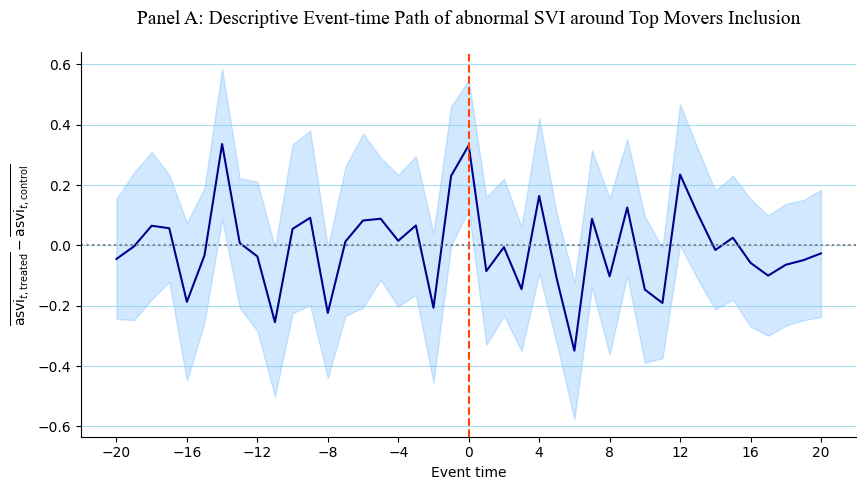

In [109]:
def summarize_event_path(panel, outcome="diff_asvi"):
    s = (
        panel.groupby("rel_time")[outcome]
             .agg(["mean", "std", "count"])
             .reset_index()
    )
    s["se"] = s["std"] / np.sqrt(s["count"])
    s["ci_low"] = s["mean"] - 1.645 * s["se"]
    s["ci_high"] = s["mean"] + 1.645 * s["se"]
    return s

desc_20 = summarize_event_path(pair_panel_20_balanced, outcome="diff_asvi")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(desc_20["rel_time"], desc_20["mean"], color="darkblue")
ax.fill_between(desc_20["rel_time"], desc_20["ci_low"], desc_20["ci_high"], color="dodgerblue", alpha=0.2)

# aesthetic
ax.axvline(0, linestyle="--", color = "orangered")
ax.axhline(0, linestyle=":", color = "grey")
ax.set_xlabel("Event time")
ax.set_ylabel(r"$\overline{\text{asvi}_{t, \text{treated}}} - \overline{\text{asvi}_{t, \text{control}}}$")
ax.set_xticks(range(-20, 21, 4))
ax.set_title(r"Panel A: Descriptive Event-time Path of abnormal SVI around Top Movers Inclusion",
             pad=20, fontsize=14, family="Times New Roman")
ax.grid(True, linestyle="-", alpha=0.7, axis="y", color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("../../../figures/PanelA_event_study_path.pdf", bbox_inches="tight")
plt.show()

This plot is the descriptive output of my matched event-study design. The idea was to isolate whether a stock’s plausible inclusion in Robinhood’s Top Movers list is associated with an unusual increase in investor attention, proxied by abnormal Google search intensity.

The logic starts with the event. A stock is treated on day $t$ if it plausibly enters the Top Movers list, meaning it satisfies the Robinhood-style eligibility rule and is among the day’s largest absolute overnight movers. In my tighter design, treatment could be further restricted to stocks with market cap just above the Robinhood eligibility cutoff, for example $(300,350]$ million USD, because those are the stocks most useful for a near-threshold comparison.

But treatment alone is not enough, because these stocks are also unusual for other reasons. A stock that lands in Top Movers often has a large return shock, a news shock, or both. So I build a matched control group on the same day using stocks just below the eligibility cutoff, typically in $[250,300)$ million USD, that have very similar absolute overnight returns. The purpose of the control is to ask: "if two stocks had similarly extreme overnight moves on the same day, but only one was likely eligible to appear in Robinhood’s Top Movers screen, did the eligible one attract more search attention afterward?" That is the core identification logic.

The outcome is not raw SVI, but abnormal SVI. For each stock-date, I compute:

$$
asvi_{i,t} = \log(1+svi_{i,t}) - \text{median}\big(\log(1+svi_{i,s})\big),
$$

where the median is taken over a pre-event estimation window, such as $[t-21,t-11]$. This transforms search intensity into a deviation from the stock’s own recent normal level. That matters because different stocks have very different baseline popularity. Tesla and a small-cap biotech can never be compared meaningfully in raw SVI levels, but they can be compared in abnormal attention relative to their own history.

Once I have treated and control stocks, I align them in event time. Event time 0 is the day of plausible Top Movers inclusion. Event time -1 is the day before, +1 the day after, and so on. For each event time $k$, I compute:

$$
\text{treated asvi}_{e,k} - \text{control asvi}_{e,k}
$$

for every matched pair $e$. Then I average those differences across all events. So the plotted line is the average treated-minus-control abnormal attention difference at each event time. The shaded band is the uncertainty around that average, typically a 90% confidence interval. That means the plot is not showing raw attention for treated stocks alone. It is showing incremental attention relative to matched controls. This is important. A positive value at event time 0 means: stocks plausibly included in Top Movers attracted more abnormal search attention than similar same-day stocks that had similar overnight return shocks but were just below the market-cap eligibility threshold.

#### Estimate the main inferential event-study on treated-minus-control differences

$$
\Delta asvi_{e,k} = \delta_t + \sum_{k\neq -1}\beta_k 1\{rel\_time = k\} + u_{e,k},
$$

Where $e$ indexes a matched treated, control pair; that is, an event. $k$ indexes event-time such that $k = -5, -4, \ldots, 0, \ldots +5$. Furthermore $\Delta asvi_{e,k}$ is the treated minus control abnormal SVI attention for pair $e$ at time $k$. The treated stock is a plausible Top Movers stock. The control stock is chosen on the same day, close in market cap, and similar in absolute overnight return. The reason for this matching is to net out the generic attention shock associated with extreme returns or contemporaneous news.

For each event time k, I create an indicator $1\{rel\_time=k\}$, which equals 1 when the observation is at event time $k$, and 0 otherwise. So if my inferential window is $[-5,+5]$, I have dummy variables for $k=-5,-4,-3,-2,0,1,2,3,4,5$. I leave one event-time dummy out. That omitted category becomes the reference period. Every included coefficient is then interpreted relative to that omitted event time. It is important to notice therefore that time $k = -1$ is our baseline period! Finally, the most important coefficient is:

$$
\beta_0
=
\Big(E[asvi^{treated}_{e,0} - asvi^{control}_{e,0}]\Big)
-
\Big(E[asvi^{treated}_{e,-1} - asvi^{control}_{e,-1}]\Big),
$$

and our assumption is that $\beta_0 > 0$.

In [102]:
import statsmodels.formula.api as smf

# Start from balanced pair panel
panel_reg = pair_panel_5_balanced.copy()

# Make sure date is datetime
panel_reg["date"] = pd.to_datetime(panel_reg["date"])

# Make rel_time categorical with -1 omitted later in the formula
panel_reg["rel_time_cat"] = panel_reg["rel_time"].astype(int).astype("category")

# Keep only rows needed by the regression and drop missings explicitly
reg_vars = ["diff_asvi", "rel_time_cat", "date", "event_id"]
panel_reg['diff_asvi'] = panel_reg['diff_asvi'].replace([np.inf, -np.inf], np.nan)
panel_reg = panel_reg[reg_vars].dropna().copy()

# Optional sanity checks
print(panel_reg.shape)
print(panel_reg.isna().sum())

# Fit model on the cleaned sample
model = smf.ols(
    formula="diff_asvi ~ C(rel_time_cat, Treatment(reference=-1)) + C(date)",
    data=panel_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_reg["event_id"].to_numpy()}
)

print(model.summary())

(35611, 4)
diff_asvi       0
rel_time_cat    0
date            0
event_id        0
dtype: int64
                            OLS Regression Results                            
Dep. Variable:              diff_asvi   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     6.796
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          4.13e-270
Time:                        20:24:17   Log-Likelihood:                -49410.
No. Observations:               35611   AIC:                         9.988e+04
Df Residuals:                   35083   BIC:                         1.044e+05
Df Model:                         527                                         
Covariance Type:              cluster                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]

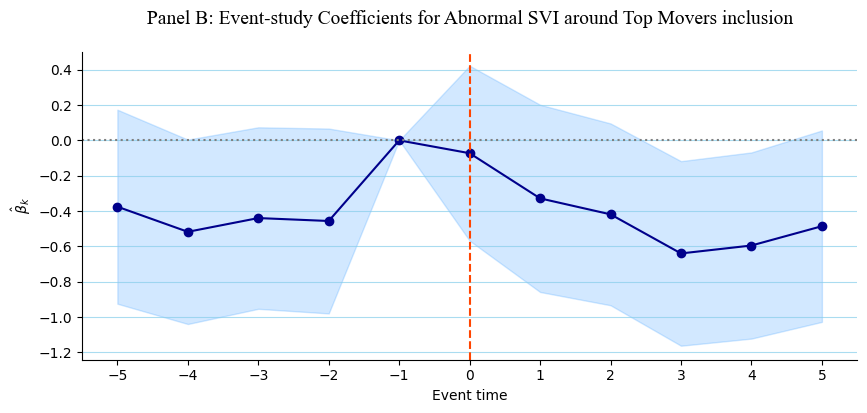

In [68]:
def extract_event_study_coefs(model, rel_times, prefix="C(rel_time_cat, Treatment(reference=-1))"):
    rows = []
    for k in rel_times:
        if k == -1:
            rows.append({"rel_time": k, "coef": 0.0, "se": 0.0})
            continue
        
        name = f"{prefix}[T.{k}]"
        if name in model.params.index:
            coef = model.params[name]
            se = model.bse[name]
        else:
            coef = np.nan
            se = np.nan
        
        rows.append({"rel_time": k, "coef": coef, "se": se})
    
    out = pd.DataFrame(rows)
    out["ci_low"] = out["coef"] - 1.645 * out["se"]
    out["ci_high"] = out["coef"] + 1.645 * out["se"]
    return out

coef_df = extract_event_study_coefs(model, rel_times=list(range(-5, 6)))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(coef_df["rel_time"], coef_df["coef"], marker="o", color="darkblue")
ax.fill_between(coef_df["rel_time"], coef_df["ci_low"], coef_df["ci_high"], alpha=0.2, color="dodgerblue")
ax.axvline(0, linestyle="--", color="orangered")
ax.axhline(0, linestyle=":", color="grey")
ax.set_xlabel("Event time")
ax.set_xticks(range(-5, 6))
ax.set_ylabel(r"$\hat{\beta}_k$")
ax.set_title("Panel B: Event-study Coefficients for Abnormal SVI around Top Movers inclusion",
             pad=20, fontsize=14, family="Times New Roman")
ax.grid(True, linestyle="-", alpha=0.7, axis="y", color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("../../../figures/PanelB_event_study_coefficients.pdf", bbox_inches="tight")
plt.show()

#### Estimate the positive and negative subsamples separately

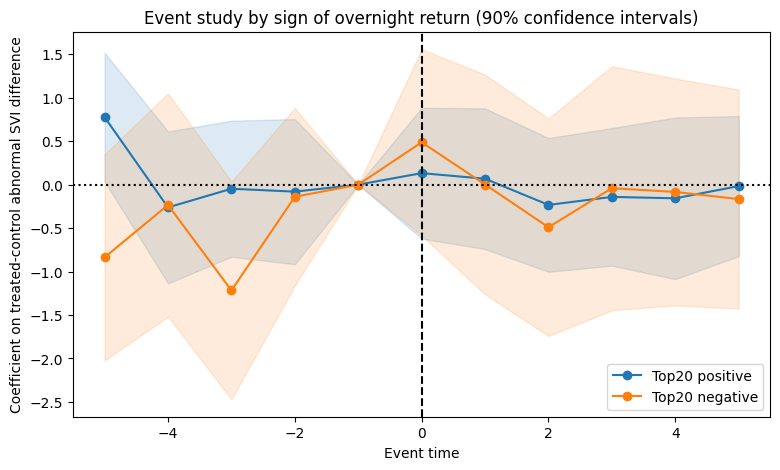

In [146]:
# ------------------------------------------------------------
# 1. BUILD SEPARATE MATCH FILES
# ------------------------------------------------------------
matches_pos = build_event_matches(
    df1,
    event_col="event_main_pos_usable"
)

matches_neg = build_event_matches(
    df1,
    event_col="event_main_neg_usable"
)

# ------------------------------------------------------------
# 2. BUILD PAIR PANELS
# ------------------------------------------------------------
panel_pos_5 = build_pair_panel_fast(df1, matches_pos, event_window=5)
panel_neg_5 = build_pair_panel_fast(df1, matches_neg, event_window=5)

# ------------------------------------------------------------
# 3. KEEP ONLY BALANCED EVENT WINDOWS
# ------------------------------------------------------------
good_pos = panel_pos_5.groupby("event_id")["rel_time"].nunique()
good_pos = good_pos.loc[good_pos == 11].index
panel_pos_5 = panel_pos_5.loc[panel_pos_5["event_id"].isin(good_pos)].copy()

good_neg = panel_neg_5.groupby("event_id")["rel_time"].nunique()
good_neg = good_neg.loc[good_neg == 11].index
panel_neg_5 = panel_neg_5.loc[panel_neg_5["event_id"].isin(good_neg)].copy()

# ------------------------------------------------------------
# 4. RUN REGRESSIONS
# ------------------------------------------------------------
def run_diff_event_reg(panel):
    panel = panel.copy()

    # Keep only the variables used in the regression and drop missings first
    # so that the clustering groups vector has exactly the same length as the
    # estimation sample used by statsmodels.
    panel = panel[["diff_asvi", "rel_time", "date", "event_id"]].dropna().copy()
    panel = panel.reset_index(drop=True)

    # Clean types
    panel["date"] = pd.to_datetime(panel["date"])
    panel["rel_time_cat"] = panel["rel_time"].astype(int).astype("category")

    # Build model first
    model_base = smf.ols(
        formula="diff_asvi ~ C(rel_time_cat, Treatment(reference=-1)) + C(date)",
        data=panel
    )

    # Align cluster groups to exact estimation sample retained by patsy/statsmodels
    used_rows = model_base.data.row_labels
    groups_used = panel.loc[used_rows, "event_id"].to_numpy()

    mod = model_base.fit(
        cov_type="cluster",
        cov_kwds={"groups": groups_used}
    )
    return mod

mod_pos = run_diff_event_reg(panel_pos_5)
mod_neg = run_diff_event_reg(panel_neg_5)

# ------------------------------------------------------------
# 5. EXTRACT EVENT-STUDY COEFFICIENTS WITH CHOSEN CI LEVEL
# ------------------------------------------------------------
def extract_event_study_coefs(
    model,
    rel_times,
    prefix="C(rel_time_cat, Treatment(reference=-1))",
    ci_level=0.90
):
    z_map = {
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576
    }
    if ci_level not in z_map:
        raise ValueError("ci_level must be one of {0.90, 0.95, 0.99}")

    z = z_map[ci_level]

    rows = []
    for k in rel_times:
        if k == -1:
            rows.append({"rel_time": k, "coef": 0.0, "se": 0.0})
            continue

        name = f"{prefix}[T.{k}]"
        if name in model.params.index:
            coef = model.params[name]
            se = model.bse[name]
        else:
            coef = np.nan
            se = np.nan

        rows.append({
            "rel_time": k,
            "coef": coef,
            "se": se
        })

    out = pd.DataFrame(rows)
    out["ci_low"] = out["coef"] - z * out["se"]
    out["ci_high"] = out["coef"] + z * out["se"]
    return out

coef_pos = extract_event_study_coefs(
    mod_pos,
    rel_times=list(range(-5, 6)),
    ci_level=0.90
)

coef_neg = extract_event_study_coefs(
    mod_neg,
    rel_times=list(range(-5, 6)),
    ci_level=0.90
)

# ------------------------------------------------------------
# 6. PLOT WITH 90% CONFIDENCE INTERVALS
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

# Positive group
plt.plot(
    coef_pos["rel_time"],
    coef_pos["coef"],
    marker="o",
    color="tab:blue",
    label="Top20 positive"
)
plt.fill_between(
    coef_pos["rel_time"],
    coef_pos["ci_low"],
    coef_pos["ci_high"],
    color="tab:blue",
    alpha=0.15
)

# Negative group
plt.plot(
    coef_neg["rel_time"],
    coef_neg["coef"],
    marker="o",
    color="tab:orange",
    label="Top20 negative"
)
plt.fill_between(
    coef_neg["rel_time"],
    coef_neg["ci_low"],
    coef_neg["ci_high"],
    color="tab:orange",
    alpha=0.15
)

plt.axvline(0, linestyle="--", color="black")
plt.axhline(0, linestyle=":", color="black")
plt.xlabel("Event time")
plt.ylabel("Coefficient on treated-control abnormal SVI difference")
plt.title("Event study by sign of overnight return (90% confidence intervals)")
plt.legend()
plt.show()

### 2.4. Discussion 

The main conclusion is the following: plausible inclusion in Robinhood’s Top Movers list is associated with a sharp, same-day increase in abnormal Google search attention relative to matched controls, but that effect is short-lived and does not survive into the next trading day. The dynamic pattern is consistent with a contemporaneous salience shock rather than a persistent attention cycle. The coefficients also tell that it seems that at time $t = -1$, we already have an increase in $\textit{asvi}_{i, t}$ which means that some news is probably already filtering in the search behavior of retail investors.

## 3. RD Test

In [19]:
# baseline trading sample
df3 = pd.read_csv('../../../data/processed/attention_sample.csv')

# parse dates
df3['date'] = pd.to_datetime(df3['date'])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_91207/1184975288.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('../../../data/processed/attention_sample.csv')


In [20]:
df3 = df3.sort_values(['ticker', 'date']).copy()

# market cap at market open in millions
df3['shrout_lag1'] = df3.groupby('ticker')['shrout'].shift(1)
df3['mktcap'] = (df3['open_price'] * df3['shrout_lag1']) / 1e3

# overnight return from previous close to today's open
df3["close_price_lag"] = df3.groupby("ticker")["close_price"].shift(1)
df3["overnight_ret"] = (df3["open_price"] / df3["close_price_lag"]) - 1

# absolute overnight return
df3["abs_overnight_ret"] = df3["overnight_ret"].abs()

# absolute return
df3["abs_ret"] = df3['ret'].abs()

# absolute intra ret
df3['intra_ret'] = (df3['close_price'] / df3['open_price']) - 1
df3['abs_intra_ret'] = df3['intra_ret'].abs()

# ! SMALL GLITCH
df3['overnight_ret'] = df3['intra_ret']
df3['abs_overnight_ret'] = df3['abs_intra_ret']

I build an abnormal measure for Google Search Volume Index.

In [21]:
# build asvi_t as ln(1 + svi_t / mean(svi_t) for t in [t-1, t-21])
def compute_asvi(group, value_col="svi"):
    s = group[value_col]
    baseline = s.shift(1).rolling(window=21).mean()
    out = group.copy()
    out["asvi_t"] = np.log1p(s / (baseline + 1))
    return out

df3 = df3.groupby("ticker", group_keys=False).apply(compute_asvi).reset_index(drop=True)

# look at the percentage of nan values in asvi_t
nan_percentage = df3["asvi_t"].isna().mean() * 100
print(f"Percentage of NaN values in asvi_t: {nan_percentage:.2f}%")

# look at the percentage of infinite (positive or negative) values in asvi_t
inf_percentage = np.isinf(df3["asvi_t"]).mean() * 100
print(f"Percentage of infinite values in asvi_t: {inf_percentage:.2f}%")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_91207/3399074424.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df3 = df3.groupby("ticker", group_keys=False).apply(compute_asvi).reset_index(drop=True)


Percentage of NaN values in asvi_t: 10.26%
Percentage of infinite values in asvi_t: 0.00%


In [6]:
df3.columns

Index(['date', 'users_close', 'users_start', 'users_last', 'intraday_userchg',
       'ticker', 'permno', 'ret', 'prc', 'vol', 'shrout', 'exchcd', 'symro',
       'symsu', 'buy_num_trades_LR', 'sell_num_trades_LR', 'total_trade_LR',
       'buy_vol_LR', 'sell_vol_LR', 'close_price', 'open_price', 'close_vol',
       'open_vol', 'total_vol_m', 'total_n_trades_m', 'intra_ret',
       'buy_num_trades_tick', 'sell_num_trades_tick', 'buy_vol_tick',
       'sell_vol_tick', 'total_trade_tick', 'buy_num_trades_wrds',
       'sell_num_trades_wrds', 'buy_vol_wrds', 'sell_vol_wrds',
       'total_trade_wrds', 'bs_ratio_num', 'bs_ratio_vol',
       'buy_num_trades_retail', 'sell_num_trades_retail', 'buy_vol_retail',
       'sell_vol_retail', 'total_trade_retail', 'total_vol_retail',
       'bs_ratio_retail_vol', 'bs_ratio_retail_num', 'intra_volatility',
       'buy_num_trades_inst50k', 'sell_num_trades_inst50k', 'buy_vol_inst50k',
       'sell_vol_inst50k', 'total_trade_inst50k', 'total_vol_inst5

In [7]:
# ============================================================
# REQUIRED COLUMNS IN df
# ------------------------------------------------------------
# date              : trading day
# ticker            : stock identifier
# mktcap            : market capitalization in million USD
# overnight_ret     : overnight return (signed)
# asvi              : intraday change in Robinhood users
# ============================================================


def build_topmover_rd_sample(
    df,
    upper_treat_cap=350,
    lower_control_cap=250,
    cutoff=300,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
):
    """
    Build an RD sample inspired by Barber et al. (2022):
    - Treated-side candidates:
        market cap in (300, upper_treat_cap]
        AND top_n by abs overnight return among stocks with mktcap > 300
    - Control-side candidates:
        market cap in [lower_control_cap, 300]
        AND abs overnight return sufficiently close to at least one treated-side candidate
          using the ratio restriction:
              abs_ret_treated / abs_ret_control in [ratio_low, ratio_high]

    Important:
    This function uses the return-based matching logic only as a SAMPLE RESTRICTION.
    The regression itself will still estimate the discontinuity at the 300 cutoff.

    Parameters
    ----------
    df : pd.DataFrame
    upper_treat_cap : float
        Upper cap bound for treated-side sample.
    lower_control_cap : float
        Lower cap bound for below-cutoff controls.
    cutoff : float
        RD threshold, usually 300.
    top_n : int
        Number of top absolute-return movers above the cutoff to keep.
    ratio_low, ratio_high : float
        Allowed range for abs_ret_treated / abs_ret_control.
    keep_all_eligible_controls : bool
        If True, keep every below-cutoff stock that matches at least one treated stock.
        If False, keep only the single closest treated-return distance match for each control.

    Returns
    -------
    rd_df : pd.DataFrame
        Restricted RD sample.
    """

    data = df.copy()
    data = data.dropna(subset=["date", "ticker", "mktcap", "overnight_ret", "asvi_t"]).copy()
    data["date"] = pd.to_datetime(data["date"])
    data["abs_overnight_ret"] = data["overnight_ret"].abs()

    out = []

    for d, g in data.groupby("date"):
        g = g.copy()

        # --------------------------------------------------------
        # 1. Above-threshold ranking among stocks with mktcap > cutoff
        # --------------------------------------------------------
        eligible_above = g[g["mktcap"] > cutoff].copy()
        if eligible_above.empty:
            continue

        eligible_above = eligible_above.sort_values("abs_overnight_ret", ascending=False)
        eligible_above["rank_above_cutoff"] = np.arange(1, len(eligible_above) + 1)

        treated = eligible_above[
            (eligible_above["mktcap"] > cutoff) &
            (eligible_above["mktcap"] <= upper_treat_cap) &
            (eligible_above["rank_above_cutoff"] <= top_n)
        ].copy()

        if treated.empty:
            continue

        treated["sample_side"] = "above"
        treated["rd_treated"] = 1

        # --------------------------------------------------------
        # 2. Below-threshold comparable controls
        # --------------------------------------------------------
        controls_pool = g[
            (g["mktcap"] >= lower_control_cap) &
            (g["mktcap"] < cutoff)
        ].copy()

        if controls_pool.empty:
            continue

        matched_controls_idx = set()
        control_best_distance = {}

        treated_abs = treated["abs_overnight_ret"].to_numpy()

        for idx, row in controls_pool.iterrows():
            c_abs = row["abs_overnight_ret"]

            # Zero-handling
            if c_abs == 0:
                valid = np.where(treated_abs == 0)[0]
                if len(valid) == 0:
                    continue
                min_dist = 0.0
            else:
                ratios = treated_abs / c_abs
                valid = np.where((ratios >= ratio_low) & (ratios <= ratio_high))[0]
                if len(valid) == 0:
                    continue
                min_dist = np.min(np.abs(treated_abs[valid] - c_abs))

            matched_controls_idx.add(idx)
            control_best_distance[idx] = min_dist

        if not matched_controls_idx:
            continue

        controls = controls_pool.loc[list(matched_controls_idx)].copy()
        controls["best_treated_absret_distance"] = controls.index.map(control_best_distance)
        controls["sample_side"] = "below"
        controls["rd_treated"] = 0

        if not keep_all_eligible_controls:
            # Optional tighter restriction:
            # for each day, keep only the most comparable below-threshold stocks
            controls = controls.sort_values("best_treated_absret_distance").copy()

        # --------------------------------------------------------
        # 3. Stack into daily RD sample
        # --------------------------------------------------------
        day_sample = pd.concat([treated, controls], axis=0, ignore_index=True)
        out.append(day_sample)

    if not out:
        return pd.DataFrame()

    rd_df = pd.concat(out, axis=0, ignore_index=True)

    # Running variable centered at cutoff
    rd_df["running"] = rd_df["mktcap"] - cutoff

    return rd_df


def run_rd_on_restricted_sample(
    rd_df,
    outcome="asvi_t",
    cutoff=300,
    degree=1,
    cluster="date"
):
    """
    Estimate:
        outcome_it = beta0
                   + beta1 * 1(mktcap >= cutoff)
                   + polynomial in (mktcap - cutoff)
                   + interactions with 1(mktcap >= cutoff)
                   + error_it

    on the restricted RD sample produced above.

    Parameters
    ----------
    rd_df : pd.DataFrame
    outcome : str
        Dependent variable.
    cutoff : float
        RD cutoff.
    degree : int
        Polynomial degree for the running variable.
    cluster : str or None
        If 'date', cluster SE by date.
        If None, use HC1 robust SE.

    Returns
    -------
    results : statsmodels result
    """

    if rd_df.empty:
        raise ValueError("rd_df is empty. No restricted RD sample was created.")

    df_reg = rd_df.copy()
    df_reg["D"] = (df_reg["mktcap"] > cutoff).astype(int)

    # Polynomial terms
    for n in range(1, degree + 1):
        df_reg[f"run{n}"] = df_reg["running"] ** n

    rhs = ["D"]
    for n in range(1, degree + 1):
        rhs.append(f"run{n}")
        rhs.append(f"D:run{n}")

    formula = f"{outcome} ~ " + " + ".join(rhs)
    model = smf.ols(formula, data=df_reg)

    if cluster == "date":
        results = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": df_reg["date"]}
        )
    else:
        results = model.fit(cov_type="HC1")

    return results


def rd_diagnostics(rd_df):
    """
    Basic diagnostics for the restricted sample.
    """
    if rd_df.empty:
        print("RD sample is empty.")
        return

    print("Total observations:", len(rd_df))
    print("Above-cutoff observations:", (rd_df["mktcap"] > 300).sum())
    print("Below-cutoff observations:", (rd_df["mktcap"] <= 300).sum())
    print("Unique dates:", rd_df["date"].nunique())
    print("Unique tickers:", rd_df["ticker"].nunique())

    print("\nMarket cap summary by side:")
    print(rd_df.groupby("sample_side")["mktcap"].describe())

    print("\nAbsolute overnight return summary by side:")
    print(rd_df.groupby("sample_side")["abs_overnight_ret"].describe())


# ============================================================
# EXAMPLE USAGE
# ============================================================

# 1. Build restricted RD sample
rd_df = build_topmover_rd_sample(
    df3,
    upper_treat_cap=300,
    lower_control_cap=200,
    cutoff=250,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
)

# 2. Diagnostics
# rd_diagnostics(rd_df)

# 3. Estimate RD with different polynomial orders
res_lin = run_rd_on_restricted_sample(rd_df, outcome="asvi_t", degree=1, cluster="date", cutoff=250)
res_quad = run_rd_on_restricted_sample(rd_df, outcome="asvi_t", degree=2, cluster="date", cutoff=250)
res_cubic = run_rd_on_restricted_sample(rd_df, outcome="asvi_t", degree=3, cluster="date", cutoff=250)

print("\n================ LINEAR RD ================\n")
print(res_lin.summary())

print("\n================ QUADRATIC RD ================\n")
print(res_quad.summary())

print("\n================ CUBIC RD ================\n")
print(res_cubic.summary())


================ LINEAR RD ================

                            OLS Regression Results                            
Dep. Variable:                 asvi_t   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.635
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0496
Time:                        12:01:55   Log-Likelihood:                -3611.9
No. Observations:                3353   AIC:                             7232.
Df Residuals:                    3349   BIC:                             7256.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

### robustness

triangular kernel weights

In [23]:
def run_local_linear_rd(
    df,
    outcome="userchg_intraday",
    cutoff=300,
    bandwidth=50,
    add_day_fe=True,
    cluster="date",
):
    """
    Local-linear RD with triangular kernel weights.

    Uses observations within +/- bandwidth around the cutoff.
    """

    required = ["mktcap", outcome, "date", "ticker"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    temp = df.dropna(subset=required).copy()
    temp["date"] = pd.to_datetime(temp["date"])
    temp["running"] = temp["mktcap"] - cutoff

    temp = temp[temp["running"].abs() <= bandwidth].copy()
    if temp.empty:
        raise ValueError("No observations inside bandwidth.")

    temp["D"] = (temp["running"] >= 0).astype(int)
    temp["D_running"] = temp["D"] * temp["running"]

    # Triangular kernel weights
    temp["w"] = 1 - (temp["running"].abs() / bandwidth)
    temp = temp[temp["w"] > 0].copy()

    rhs = ["D", "running", "D_running"]
    if add_day_fe:
        rhs += ["C(date)"]

    formula = f"{outcome} ~ " + " + ".join(rhs)

    model = smf.wls(formula, data=temp, weights=temp["w"])

    if cluster == "date":
        res = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": temp["date"]}
        )
    elif cluster == "ticker_date":
        groups = pd.DataFrame({
            "ticker": temp["ticker"].astype("category").cat.codes,
            "date": temp["date"].astype("category").cat.codes,
        })
        res = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": groups}
        )
    elif cluster is None:
        res = model.fit(cov_type="HC1")
    else:
        raise ValueError("cluster must be one of {'date', 'ticker_date', None}")

    return res, temp

In [24]:
def local_linear_bandwidth_table(
    df,
    outcome="userchg_intraday",
    cutoff=300,
    bandwidths=(50, 75, 100, 125),
    cluster="date",
):
    out = []

    for bw in bandwidths:
        res, used = run_local_linear_rd(
            df,
            outcome=outcome,
            cutoff=cutoff,
            bandwidth=bw,
            add_day_fe=True,
            cluster=cluster,
        )

        d = extract_rd_result(res, label=outcome)
        d["bandwidth"] = bw
        d["mean_dep"] = used[outcome].mean()
        d["nobs"] = int(res.nobs)
        out.append(d)

    return pd.DataFrame(out)

def extract_rd_result(res, label=None):
    return {
        "label": label,
        "coef": res.params.get("D", np.nan),
        "se": res.bse.get("D", np.nan),
        "t": res.tvalues.get("D", np.nan),
        "p": res.pvalues.get("D", np.nan),
        "nobs": int(res.nobs),
        "r2": res.rsquared,
    }

In [29]:
rd_df = build_topmover_rd_sample(
    df3,
    upper_treat_cap=375,
    lower_control_cap=225,
    cutoff=300,
    top_n=20,
    ratio_low=0.5,
    ratio_high=2.0,
    keep_all_eligible_controls=True
)

ll_userchg = local_linear_bandwidth_table(
    rd_df,
    outcome="asvi_t",
    cutoff=300,
    bandwidths=(50, 75),
    cluster="date",
)

print(ll_userchg)

    label      coef        se         t         p  nobs        r2  bandwidth  \
0  asvi_t  0.186290  0.077736  2.396458  0.016554  3639  0.164041         50   
1  asvi_t  0.152538  0.061767  2.469558  0.013528  5488  0.116302         75   

   mean_dep  
0  0.458576  
1  0.461983  


In [27]:
rd_df.head()

""


___

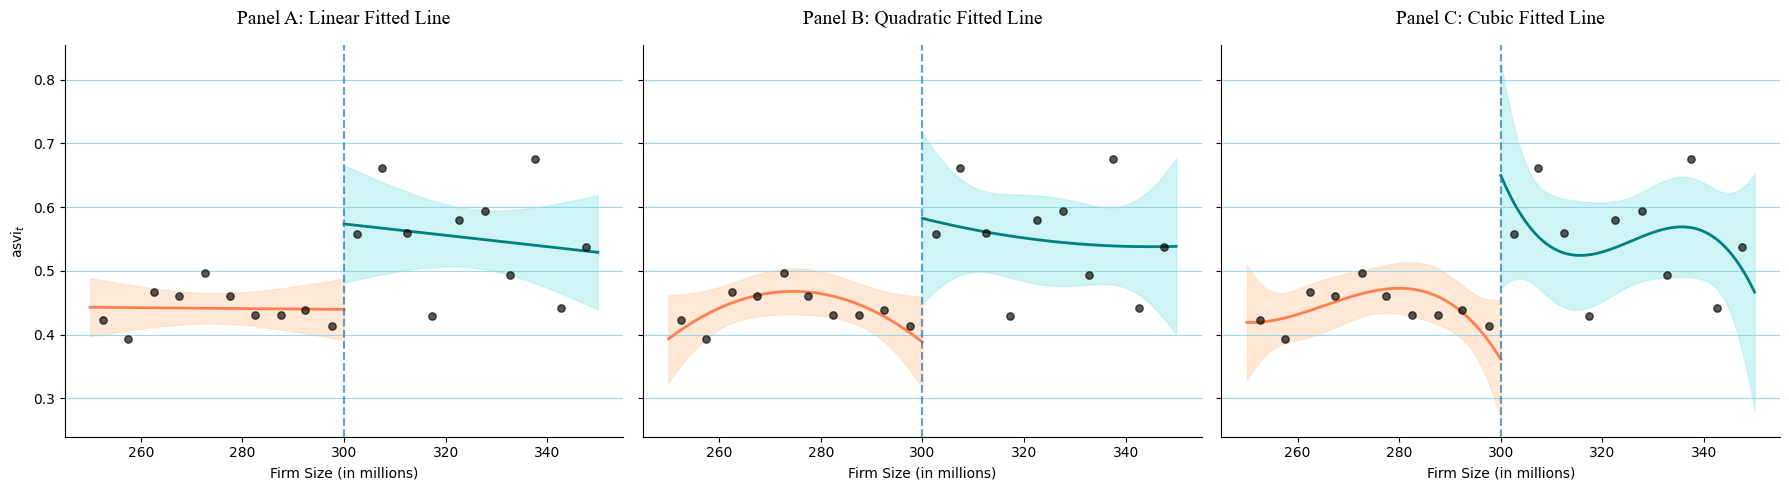

In [10]:
def _make_binned_scatter(
    df,
    x_col="mktcap",
    y_col="asvi_t",
    cutoff=300,
    n_bins_each_side=10
):
    """
    Create binned scatterplot data separately below and above the cutoff.
    Returns one dataframe with bin-level mean x and mean y.
    """
    d = df[[x_col, y_col]].dropna().copy()

    below = d[d[x_col] <= cutoff].copy()
    above = d[d[x_col] > cutoff].copy()

    binned_parts = []

    # Below-cutoff bins
    if len(below) > 0:
        below["bin"] = pd.cut(
            below[x_col],
            bins=np.linspace(below[x_col].min(), cutoff, n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )
        b0 = below.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            n=(y_col, "size")
        ).dropna().reset_index(drop=True)
        binned_parts.append(b0)

    # Above-cutoff bins
    if len(above) > 0:
        above["bin"] = pd.cut(
            above[x_col],
            bins=np.linspace(cutoff, above[x_col].max(), n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )
        b1 = above.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean"),
            n=(y_col, "size")
        ).dropna().reset_index(drop=True)
        binned_parts.append(b1)

    if not binned_parts:
        return pd.DataFrame(columns=["x_mean", "y_mean", "n"])

    return pd.concat(binned_parts, ignore_index=True)


def _fit_side_polynomial(side_df, degree, x_col="mktcap", y_col="asvi_t"):
    """
    Fit polynomial regression separately on one side of the cutoff:
        y = beta0 + beta1*x + beta2*x^2 + ...
    Returns fitted model.
    """
    d = side_df[[x_col, y_col]].dropna().copy()

    X = pd.DataFrame({"const": 1.0}, index=d.index)
    for p in range(1, degree + 1):
        X[f"x{p}"] = d[x_col] ** p

    model = sm.OLS(d[y_col], X).fit()
    return model


def _predict_side(model, x_grid, degree):
    """
    Get fitted values and 90% CI on a grid for one side.
    """
    Xg = pd.DataFrame({"const": np.ones(len(x_grid))})
    for p in range(1, degree + 1):
        Xg[f"x{p}"] = x_grid ** p

    pred = model.get_prediction(Xg).summary_frame(alpha=0.10)  # 90% CI
    out = pd.DataFrame({
        "x": x_grid,
        "yhat": pred["mean"].to_numpy(),
        "ci_low": pred["mean_ci_lower"].to_numpy(),
        "ci_high": pred["mean_ci_upper"].to_numpy()
    })
    return out


def plot_barber_figure5_style(
    rd_df,
    x_col="mktcap",
    y_col="asvi_t",
    cutoff=300,
    degrees=(1, 2, 3),
    n_bins_each_side=10,
    figsize=(18, 5),
    point_alpha=0.65,
    line_width=2.0,
    ci_alpha=0.6
):
    """
    Reproduce a Figure 5 style RD plot:
    - binned scatterplot
    - separate fits below/above cutoff
    - 90% confidence bands
    - linear, quadratic, cubic panels on one row
    """

    d = rd_df[[x_col, y_col]].dropna().copy()

    # Binned scatter data
    binned = _make_binned_scatter(
        d,
        x_col=x_col,
        y_col=y_col,
        cutoff=cutoff,
        n_bins_each_side=n_bins_each_side
    )

    below = d[d[x_col] <= cutoff].copy()
    above = d[d[x_col] > cutoff].copy()

    fig, axes = plt.subplots(1, len(degrees), figsize=figsize, sharey=True)

    if len(degrees) == 1:
        axes = [axes]

    panel_titles = {
        1: "Panel A: Linear Fitted Line",
        2: "Panel B: Quadratic Fitted Line",
        3: "Panel C: Cubic Fitted Line"
    }

    for ax, deg in zip(axes, degrees):
        # ----------------------------------------------------
        # 1. Binned scatter
        # ----------------------------------------------------
        ax.scatter(
            binned["x_mean"],
            binned["y_mean"],
            alpha=point_alpha,
            s=28,
            color="black",
            zorder=3
        )

        # ----------------------------------------------------
        # 2. Separate polynomial fits below and above cutoff
        # ----------------------------------------------------
        if len(below) > 0:
            model_below = _fit_side_polynomial(below, degree=deg, x_col=x_col, y_col=y_col)
            xg_below = np.linspace(below[x_col].min(), cutoff, 200)
            pred_below = _predict_side(model_below, xg_below, degree=deg)

            ax.plot(pred_below["x"], pred_below["yhat"], linewidth=line_width, color="coral")
            ax.fill_between(
                pred_below["x"],
                pred_below["ci_low"],
                pred_below["ci_high"],
                alpha=ci_alpha,
                color="peachpuff"
            )

        if len(above) > 0:
            model_above = _fit_side_polynomial(above, degree=deg, x_col=x_col, y_col=y_col)
            xg_above = np.linspace(cutoff, above[x_col].max(), 200)
            pred_above = _predict_side(model_above, xg_above, degree=deg)

            ax.plot(pred_above["x"], pred_above["yhat"], linewidth=line_width, color="teal")
            ax.fill_between(
                pred_above["x"],
                pred_above["ci_low"],
                pred_above["ci_high"],
                alpha=ci_alpha,
                color="paleturquoise"
            )

        # ----------------------------------------------------
        # 3. Cutoff line and formatting
        # ----------------------------------------------------
        ax.axvline(cutoff, linestyle="--", alpha=0.7)
        ax.set_title(panel_titles.get(deg, f"Degree {deg}"), fontsize=14, family="Times New Roman", pad=15)
        ax.set_xlabel("Firm Size (in millions)")
        ax.grid(axis="y", alpha=0.8, color="skyblue")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(r"$\text{asvi}_t$")

    plt.tight_layout()
    plt.savefig("../../../figures/Barber_Figure5_Style_ASVI.pdf", bbox_inches="tight")
    plt.show()


# ============================================================
# RUN THE FIGURE
# ============================================================

plot_barber_figure5_style(
    rd_df,
    x_col="mktcap",
    y_col="asvi_t",
    cutoff=300,
    degrees=(1, 2, 3),
    n_bins_each_side=10,   # 10 bins below + 10 bins above, close to the published figure
    figsize=(18, 5)
)

EXTREMELLY INTERESTING FINDING AND STATISTICALLY SIGNIFICANT!

#### results with 50 bandwith

#### 75 bandwith

#### 100 

#### 125

#### placebo

## Stein (2020)

Load data

In [31]:
# ------------------------------------------------------------
# 0. Load data
# ------------------------------------------------------------

df4 = pd.read_csv('../../../data/processed/herding_events_full.csv')
df4['date'] = pd.to_datetime(df4['date'])

# Use ticker as the stock identifier.
ID_COL = 'ticker'

# Basic cleaning
df = df4.copy()
df = df.dropna(subset=['date', ID_COL, 'users_close'])

# Make sure observations are uniquely identified by stock-date
dups = df.duplicated(subset=[ID_COL, 'date']).sum()
print(f"Duplicate stock-date observations: {dups}")

if dups > 0:
    # Conservative fix: keep the observation with the largest users_close.
    # You can replace this with your own deduplication rule if needed.
    df = (
        df.sort_values(['date', ID_COL, 'users_close'])
          .drop_duplicates(subset=[ID_COL, 'date'], keep='last')
    )

df = df.sort_values([ID_COL, 'date']).reset_index(drop=True)


# ------------------------------------------------------------
# 1. Build Top 100 indicator
# ------------------------------------------------------------

# Rank stocks within each trading day by users_close.
# method='first' forces exactly 100 stocks per day, even if there are ties.
df['rh_rank_users_close'] = (
    df.groupby('date')['users_close']
      .rank(method='first', ascending=False)
)

df['top_100_uc'] = (df['rh_rank_users_close'] <= 100).astype(int)

# Sanity check: should be 100 per day, except if fewer than 100 stocks exist on a day.
top100_counts = df.groupby('date')['top_100_uc'].sum()
print(top100_counts.describe())


# ------------------------------------------------------------
# 2. Build Top 100 entry indicator
# ------------------------------------------------------------

df['top_100_uc_lag1'] = (
    df.groupby(ID_COL)['top_100_uc']
      .shift(1)
)

df['date_lag1'] = (
    df.groupby(ID_COL)['date']
      .shift(1)
)

# This checks whether the previous stock observation is the previous trading day
# in the panel, not merely any earlier available date.
trading_days = pd.Series(sorted(df['date'].unique()))
trading_day_map = pd.Series(np.arange(len(trading_days)), index=trading_days)

df['td'] = df['date'].map(trading_day_map)
df['td_lag1'] = df.groupby(ID_COL)['td'].shift(1)
df['has_previous_trading_day_obs'] = (df['td'] - df['td_lag1'] == 1)

df['top_100_entry'] = (
    (df['top_100_uc'] == 1) &
    (df['top_100_uc_lag1'] == 0) &
    (df['has_previous_trading_day_obs'])
).astype(int)

print("Raw Top 100 entry events:", df['top_100_entry'].sum())

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_91207/275773780.py:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv('../../../data/processed/herding_events_full.csv')


Duplicate stock-date observations: 0
count    554.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: top_100_uc, dtype: float64
Raw Top 100 entry events: 455


Now construct the clean event sample. The strict definition below excludes oscillating stocks by requiring that, around the event window, the stock is outside the Top 100 during all pre-event days [-10,-1] and inside the Top 100 during all post-event days [0,+10]. This is a clean “entry into the list” design. It also avoids stocks that enter, exit, and re-enter within the same event window.

In [38]:
# ------------------------------------------------------------
# 3. Construct clean Top 100 entry events
# ------------------------------------------------------------

EVENT_WINDOW_PRE = 10
EVENT_WINDOW_POST = 10

# Choose stock identifier
# Prefer permno if it is clean and available; otherwise use ticker.
ID_COL = 'permno'   # or 'ticker'

event_cols = [ID_COL, 'date']

# Add ticker only if it is not already the identifier
if ID_COL != 'ticker':
    event_cols.append('ticker')

events = df.loc[df['top_100_entry'] == 1, event_cols].copy()
events = events.rename(columns={'date': 'event_date'})
events['event_id'] = np.arange(len(events))

print("Candidate events:", len(events))

# Count number of Top 100 entries per stock
events['n_entries_stock'] = (
    events.groupby(ID_COL)['event_id']
          .transform('count')
)

events_strict_once = events.loc[events['n_entries_stock'] == 1].copy()

print("Events after requiring one entry per stock:", len(events_strict_once))


# ------------------------------------------------------------
# 4. Attach event-time windows
# ------------------------------------------------------------

# Keep only variables needed for the event study
panel = df[[
    ID_COL, 'ticker', 'date', 'td',
    'users_close', 'userchg', 'top_100_uc', 'top_100_entry', 'ret'
]].copy()

event_windows = []

for _, ev in events_strict_once.iterrows():
    stock_id = ev[ID_COL]
    event_td = trading_day_map.loc[ev['event_date']]
    
    tmp = panel.loc[
        (panel[ID_COL] == stock_id) &
        (panel['td'].between(event_td - EVENT_WINDOW_PRE, event_td + EVENT_WINDOW_POST))
    ].copy()
    
    tmp['event_id'] = ev['event_id']
    tmp['event_date'] = ev['event_date']
    tmp['event_time'] = tmp['td'] - event_td
    
    event_windows.append(tmp)

event_df = pd.concat(event_windows, ignore_index=True)

# Keep only complete event windows
n_required = EVENT_WINDOW_PRE + EVENT_WINDOW_POST + 1

complete_events = (
    event_df.groupby('event_id')['event_time']
    .nunique()
    .loc[lambda x: x == n_required]
    .index
)

event_df = event_df.loc[event_df['event_id'].isin(complete_events)].copy()

print("Events with complete [-10,+10] windows:", event_df['event_id'].nunique())


# ------------------------------------------------------------
# 5. Exclude oscillating events inside the event window
# ------------------------------------------------------------

def is_clean_top100_entry(g):
    """
    Clean event definition:
    - stock is outside Top 100 for all event days -10,...,-1
    - stock is inside Top 100 for all event days 0,...,+10
    """
    pre = g.loc[g['event_time'].between(-EVENT_WINDOW_PRE, -1), 'top_100_uc']
    post = g.loc[g['event_time'].between(0, EVENT_WINDOW_POST), 'top_100_uc']
    
    return (pre.eq(0).all()) and (post.eq(1).all())

clean_event_ids = (
    event_df.groupby('event_id')
    .apply(is_clean_top100_entry)
    .loc[lambda x: x]
    .index
)

event_df_clean = event_df.loc[event_df['event_id'].isin(clean_event_ids)].copy()

print("Clean non-oscillating events:", event_df_clean['event_id'].nunique())

Candidate events: 455
Events after requiring one entry per stock: 226
Events with complete [-10,+10] windows: 70
Clean non-oscillating events: 49


/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_91207/3376134530.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(is_clean_top100_entry)


In [48]:
# ------------------------------------------------------------
# 6. Event-time path of userchg
# ------------------------------------------------------------

event_path = (
    event_df_clean
    .groupby('event_time')
    .agg(
        mean_userchg=('userchg', 'mean'),
        median_userchg=('userchg', 'median'),
        sd_userchg=('userchg', 'std'),
        n_events=('event_id', 'nunique'),
        n_obs=('userchg', 'count')
    )
    .reset_index()
)

event_path['se_userchg'] = event_path['sd_userchg'] / np.sqrt(event_path['n_obs'])
event_path['ci95_low'] = event_path['mean_userchg'] - 1.645 * event_path['se_userchg']
event_path['ci95_high'] = event_path['mean_userchg'] + 1.645 * event_path['se_userchg']

print(event_path)

    event_time  mean_userchg  median_userchg    sd_userchg  n_events  n_obs  \
0          -10    422.914894           174.0    545.562368        49     47   
1           -9    513.812500           162.0    832.351441        49     48   
2           -8    667.652174           153.5   1238.636997        49     46   
3           -7    693.551020           227.0   1561.116668        49     49   
4           -6    729.333333           217.5   1048.699607        49     48   
5           -5    874.145833           295.5   1232.755726        49     48   
6           -4   1054.795918           327.0   1557.411006        49     49   
7           -3   1732.234043           498.0   3097.220649        49     47   
8           -2   2214.612245           593.0   4139.535838        49     49   
9           -1   4799.187500          2023.0   7378.952825        49     48   
10           0   8670.479167          4113.0  12489.866342        49     48   
11           1   6348.562500          1986.0   9406.

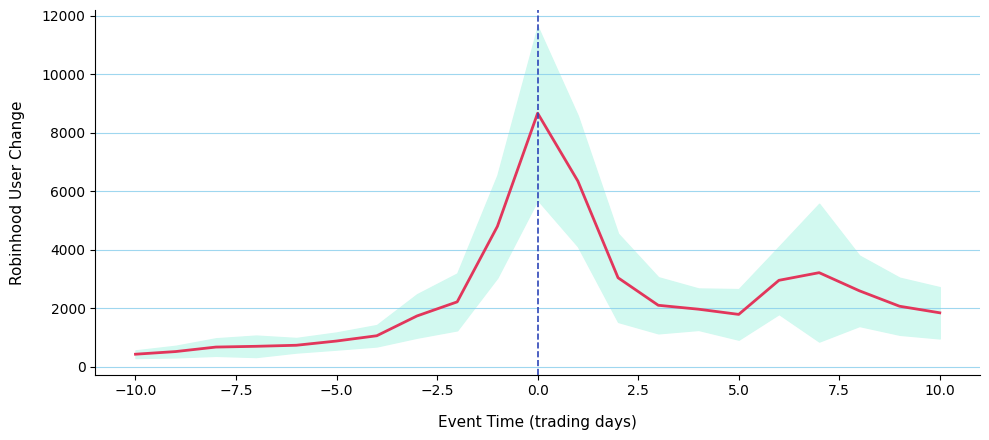

In [68]:
# ------------------------------------------------------------
# 7. Plot event-time path
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    event_path['event_time'],
    event_path['mean_userchg'],
    linewidth=2,
    label='Mean user change',
    color="#E2365B"
)

ax.fill_between(
    event_path['event_time'],
    event_path['ci95_low'],
    event_path['ci95_high'],
    alpha=1,
    label='90% CI',
    color="#D2F9F0"
)

ax.axvline(0, linestyle='--', linewidth=1.2, color="#2E45B8")

ax.set_xlabel('Event Time (trading days)', fontsize=11, labelpad=12)
ax.set_ylabel('Robinhood User Change', fontsize=11, labelpad=12)
# ax.set_title('Event-Time Path of Robinhood User Changes around Top 100 Entry')
# ax.legend()
ax.grid(True, alpha=0.8, color='skyblue', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../../figures/Top100Entry_EventPath.pdf", bbox_inches="tight")
plt.show()

In [41]:
# ------------------------------------------------------------
# 8. Diagnostics
# ------------------------------------------------------------

# Number of events by event date
events_by_day = (
    event_df_clean.loc[event_df_clean['event_time'] == 0]
    .groupby('date')['event_id']
    .nunique()
    .describe()
)

print("Events per event day:")
print(events_by_day)

# Check that the clean sample really behaves as intended
check_clean = (
    event_df_clean
    .pivot_table(
        index='event_time',
        values='top_100_uc',
        aggfunc='mean'
    )
)

print("Average Top 100 status by event time:")
print(check_clean)

# Event-day observations
event_day_obs = event_df_clean.loc[event_df_clean['event_time'] == 0].copy()

print("Event-day users_close summary:")
print(event_day_obs['users_close'].describe())

print("Event-day userchg summary:")
print(event_day_obs['userchg'].describe())

Events per event day:
count    44.000000
mean      1.113636
std       0.321038
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: event_id, dtype: float64
Average Top 100 status by event time:
            top_100_uc
event_time            
-10                0.0
-9                 0.0
-8                 0.0
-7                 0.0
-6                 0.0
-5                 0.0
-4                 0.0
-3                 0.0
-2                 0.0
-1                 0.0
 0                 1.0
 1                 1.0
 2                 1.0
 3                 1.0
 4                 1.0
 5                 1.0
 6                 1.0
 7                 1.0
 8                 1.0
 9                 1.0
 10                1.0
Event-day users_close summary:
count       49.000000
mean     37974.020408
std      22539.601908
min       8898.000000
25%      19682.000000
50%      35765.000000
75%      53238.000000
max      92086.000000
Name: users_close, dt

Now I look at whether we observe such a thing in TAQ data (we should not).

In [71]:
event_df_clean.head(22)

,permno,ticker,date,td,users_close,userchg,top_100_uc,top_100_entry,ret,event_id,event_date,event_time
0,21020.0,AAL,2020-02-20,433,11457.0,-23.0,0,0,0.006354,0,2020-03-06,-10
1,21020.0,AAL,2020-02-21,434,11567.0,110.0,0,0,-0.024202,0,2020-03-06,-9
2,21020.0,AAL,2020-02-24,435,12390.0,823.0,0,0,-0.085190,0,2020-03-06,-8
3,21020.0,AAL,2020-02-25,436,13169.0,779.0,0,0,-0.091552,0,2020-03-06,-7
4,21020.0,AAL,2020-02-26,437,13826.0,657.0,0,0,-0.035035,0,2020-03-06,-6
5,21020.0,AAL,2020-02-27,438,14404.0,578.0,0,0,-0.076647,0,2020-03-06,-5
6,21020.0,AAL,2020-02-28,439,15478.0,1074.0,0,0,-0.075243,0,2020-03-06,-4
7,21020.0,AAL,2020-03-03,440,19550.0,NaN,0,0,-0.053553,0,2020-03-06,-3
8,21020.0,AAL,2020-03-04,441,22054.0,2504.0,0,0,0.038095,0,2020-03-06,-2
9,21020.0,AAL,2020-03-05,442,25555.0,3501.0,0,0,-0.134377,0,2020-03-06,-1


In [137]:
# take taq data
taq = df4.copy()
taq['date'] = pd.to_datetime(taq['date'])
taq = taq[['ticker', 'date', 'net_buys', 'userchg']].copy()

# create total_net_buys as the sum of net_buys across all stocks for each date
taq['total_net_buys'] = taq.groupby('date')['net_buys'].transform('sum')

# create total_usrchg as the sum of usrchg across all stocks for each date
taq['total_usrchg'] = taq.groupby('date')['userchg'].transform('sum')

# drop userchg columns since already present in event_df_clean
taq = taq.drop(columns=['userchg'])

taq.head()

,ticker,date,net_buys,total_net_buys,total_usrchg
0,A,2018-05-02,1.0,63273.0,0.0
1,A,2018-05-03,-43.0,52851.0,0.0
2,A,2018-05-04,7.0,5070.0,-329.0
3,A,2018-05-07,-18.0,31832.0,0.0
4,A,2018-05-08,-11.0,56698.0,0.0


I then merge this to `event_df_clean()`

In [138]:
# merge
event_taq = pd.merge(
    event_df_clean,
    taq,
    on=['ticker', 'date'],
    how='left'
)

In [139]:
# compute share of total net buys and total user change for each stock-day
event_taq['share_net_buys'] = event_taq['net_buys'] / event_taq['total_net_buys']
event_taq['share_userchg'] = event_taq['userchg'] / event_taq['total_usrchg']
event_taq.head()

,permno,ticker,date,td,users_close,userchg,top_100_uc,top_100_entry,ret,event_id,event_date,event_time,net_buys,total_net_buys,total_usrchg,share_net_buys,share_userchg
0,21020.0,AAL,2020-02-20,433,11457.0,-23.0,0,0,0.006354,0,2020-03-06,-10,-112.0,172800.0,81387.0,-0.000648,-0.000283
1,21020.0,AAL,2020-02-21,434,11567.0,110.0,0,0,-0.024202,0,2020-03-06,-9,666.0,175482.0,61626.0,0.003795,0.001785
2,21020.0,AAL,2020-02-24,435,12390.0,823.0,0,0,-0.085190,0,2020-03-06,-8,3604.0,312370.0,93550.0,0.011538,0.008797
3,21020.0,AAL,2020-02-25,436,13169.0,779.0,0,0,-0.091552,0,2020-03-06,-7,1908.0,214261.0,36354.0,0.008905,0.021428
4,21020.0,AAL,2020-02-26,437,13826.0,657.0,0,0,-0.035035,0,2020-03-06,-6,1945.0,253185.0,90555.0,0.007682,0.007255


I compute the event-paths again:

In [140]:
# ------------------------------------------------------------
# 6. Event-time path of userchg
# ------------------------------------------------------------
event_path_taq = (
    event_taq
    .groupby('event_time')
    .agg(
        mean_userchg=('userchg', 'mean'),
        median_userchg=('userchg', 'median'),
        sd_userchg=('userchg', 'std'),
        share_userchg_mean=('share_userchg', 'mean'),
        share_userchg_sd=('share_userchg', 'std'),
        mean_net_buys=('net_buys', 'mean'),
        median_net_buys=('net_buys', 'median'),
        sd_net_buys=('net_buys', 'std'),
        share_net_buys_mean=('share_net_buys', 'mean'),
        share_net_buys_sd=('share_net_buys', 'std'),    
        n_events=('event_id', 'nunique'),
        n_obs=('userchg', 'count')
    )
    .reset_index()
)

event_path_taq['se_userchg'] = event_path_taq['sd_userchg'] / np.sqrt(event_path_taq['n_obs'])
event_path_taq['ci90_low'] = event_path_taq['mean_userchg'] - 1.645 * event_path_taq['se_userchg']
event_path_taq['ci90_high'] = event_path_taq['mean_userchg'] + 1.645 * event_path_taq['se_userchg']
event_path_taq['se_net_buys'] = event_path_taq['sd_net_buys'] / np.sqrt(event_path_taq['n_obs'])
event_path_taq['ci90_low_net_buys'] = event_path_taq['mean_net_buys'] - 1.645 * event_path_taq['se_net_buys']
event_path_taq['ci90_high_net_buys'] = event_path_taq['mean_net_buys'] + 1.645 * event_path_taq['se_net_buys']

print(event_path_taq)

    event_time  mean_userchg  median_userchg    sd_userchg  \
0          -10    422.914894           174.0    545.562368   
1           -9    513.812500           162.0    832.351441   
2           -8    667.652174           153.5   1238.636997   
3           -7    693.551020           227.0   1561.116668   
4           -6    729.333333           217.5   1048.699607   
5           -5    874.145833           295.5   1232.755726   
6           -4   1054.795918           327.0   1557.411006   
7           -3   1732.234043           498.0   3097.220649   
8           -2   2214.612245           593.0   4139.535838   
9           -1   4799.187500          2023.0   7378.952825   
10           0   8670.479167          4113.0  12489.866342   
11           1   6348.562500          1986.0   9406.997818   
12           2   3039.163265          1149.0   6431.429667   
13           3   2097.416667           876.0   4043.136448   
14           4   1963.500000           995.0   2986.066651   
15      

I plot the `net_buys`

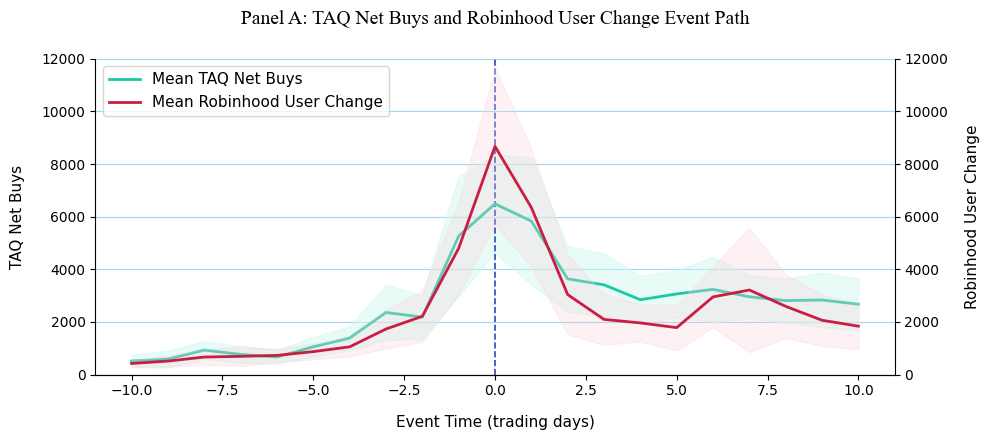

In [149]:
# ------------------------------------------------------------
# 7. Plot event-time path with two y-axes
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 4.5))

# Left y-axis: TAQ net buys
line1 = ax1.plot(
    event_path_taq['event_time'],
    event_path_taq['mean_net_buys'],
    linewidth=2,
    label='Mean TAQ Net Buys',
    color="#1DC9A4",
    zorder=12
)

ax1.fill_between(
    event_path_taq['event_time'],
    event_path_taq['ci90_low_net_buys'],
    event_path_taq['ci90_high_net_buys'],
    alpha=0.5,
    label='90% CI for TAQ net buys',
    color="#D2F9F0",
    zorder=2
)

ax1.set_xlabel('Event Time (trading days)', fontsize=11, labelpad=12)
ax1.set_ylabel('TAQ Net Buys', fontsize=11, labelpad=12)


# Right y-axis: Robinhood user change
ax2 = ax1.twinx()

line2 = ax2.plot(
    event_path_taq['event_time'],
    event_path_taq['mean_userchg'],
    linewidth=2,
    label='Mean Robinhood User Change',
    color="#C91D42",
    linestyle='-',
    zorder=7
)

ax2.fill_between(
    event_path_taq['event_time'],
    event_path_taq['ci90_low'],
    event_path_taq['ci90_high'],
    alpha=0.3,
    label='90% CI for user change',
    color="#F9D2DB",
    zorder=3
)

ax2.set_ylabel('Robinhood User Change', fontsize=11, labelpad=12)

# Event line
ax1.axvline(0, linestyle='--', linewidth=1.2, color="#2E45B8")

# Force both y-axes to use the same scale
ymin = min(
    event_path_taq['ci90_low_net_buys'].min(),
    event_path_taq['ci90_low'].min()
)

ymax = max(
    event_path_taq['ci90_high_net_buys'].max(),
    event_path_taq['ci90_high'].max()
)

ax1.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)

# Optional: same tick positions
ticks = np.arange(0, ymax + 2000, 2000)
ax1.set_yticks(ticks)
ax2.set_yticks(ticks)

# Grid and styling
ax1.grid(True, alpha=0.8, color='skyblue', axis='y')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Optional: hide right/left extra spines if needed
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, fontsize=11)

# Set title
ax1.set_title('Panel A: TAQ Net Buys and Robinhood User Change Event Path', fontsize=14, pad=25, family="Times New Roman")

plt.tight_layout()
plt.savefig("../../../figures/Top100Entry_EventPath_TAQ.pdf", bbox_inches="tight")
plt.show()

### returns

In [66]:
# ------------------------------------------------------------
# Event-time path of raw returns around Top 100 entry
# ------------------------------------------------------------
ret_event_path = (
    event_df_clean
    .dropna(subset=['ret'])
    .groupby('event_time')
    .agg(
        mean_ret=('ret', 'mean'),
        median_ret=('ret', 'median'),
        sd_ret=('ret', 'std'),
        n_events=('event_id', 'nunique'),
        n_obs=('ret', 'count')
    )
    .reset_index()
)

ret_event_path['se_ret'] = ret_event_path['sd_ret'] / np.sqrt(ret_event_path['n_obs'])
ret_event_path['ci90_low'] = ret_event_path['mean_ret'] - 1.645 * ret_event_path['se_ret']
ret_event_path['ci90_high'] = ret_event_path['mean_ret'] + 1.645 * ret_event_path['se_ret']

# Optional: percent formatting for inspection
ret_event_path['mean_ret_pct'] = 100 * ret_event_path['mean_ret']
ret_event_path['ci90_low_pct'] = 100 * ret_event_path['ci90_low']
ret_event_path['ci90_high_pct'] = 100 * ret_event_path['ci90_high']

print(ret_event_path)

    event_time  mean_ret  median_ret    sd_ret  n_events  n_obs    se_ret  \
0          -10  0.011685   -0.000866  0.086404        49     49  0.012343   
1           -9 -0.011483    0.000000  0.099742        49     49  0.014249   
2           -8 -0.008920   -0.011392  0.113489        49     49  0.016213   
3           -7 -0.021512   -0.004962  0.088460        49     49  0.012637   
4           -6 -0.011667    0.000000  0.074495        49     49  0.010642   
5           -5  0.018230    0.013899  0.085813        49     49  0.012259   
6           -4 -0.000584    0.002123  0.110965        49     49  0.015852   
7           -3  0.001311   -0.005964  0.143521        49     49  0.020503   
8           -2  0.025648    0.002211  0.151639        49     49  0.021663   
9           -1  0.119215    0.004391  0.557506        49     49  0.079644   
10           0  0.102361    0.021116  0.345052        49     49  0.049293   
11           1  0.058705   -0.010040  0.225501        49     49  0.032214   

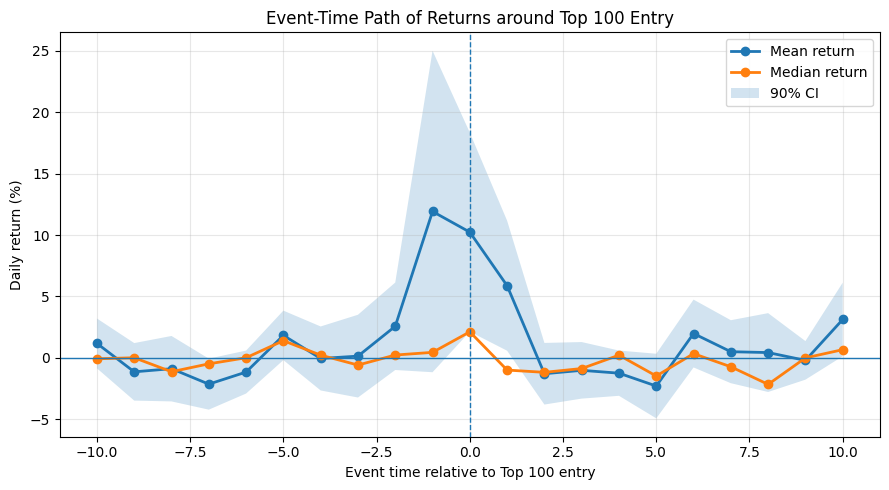

In [121]:
# ------------------------------------------------------------
# Plot event-time path of raw returns
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    ret_event_path['event_time'],
    ret_event_path['mean_ret_pct'],
    marker='o',
    linewidth=2,
    label='Mean return'
)

ax.plot(
    ret_event_path['event_time'],
    ret_event_path['median_ret'] * 100,
    marker='o',
    linewidth=2,
    label='Median return'
)

ax.fill_between(
    ret_event_path['event_time'],
    ret_event_path['ci90_low_pct'],
    ret_event_path['ci90_high_pct'],
    alpha=0.2,
    label='90% CI'
)

ax.axvline(0, linestyle='--', linewidth=1)
ax.axhline(0, linewidth=1)

ax.set_xlabel('Event time relative to Top 100 entry')
ax.set_ylabel('Daily return (%)')
ax.set_title('Event-Time Path of Returns around Top 100 Entry')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [125]:
df4.columns

Index(['date', 'users_close', 'users_start', 'users_last', 'intraday_userchg',
       'ticker', 'permno', 'ret', 'prc', 'vol', 'shrout', 'exchcd', 'symro',
       'symsu', 'buy_num_trades_LR', 'sell_num_trades_LR', 'total_trade_LR',
       'buy_vol_LR', 'sell_vol_LR', 'close_price', 'open_price', 'close_vol',
       'open_vol', 'total_vol_m', 'total_n_trades_m', 'intra_ret',
       'buy_num_trades_tick', 'sell_num_trades_tick', 'buy_vol_tick',
       'sell_vol_tick', 'total_trade_tick', 'buy_num_trades_wrds',
       'sell_num_trades_wrds', 'buy_vol_wrds', 'sell_vol_wrds',
       'total_trade_wrds', 'bs_ratio_num', 'bs_ratio_vol',
       'buy_num_trades_retail', 'sell_num_trades_retail', 'buy_vol_retail',
       'sell_vol_retail', 'total_trade_retail', 'total_vol_retail',
       'bs_ratio_retail_vol', 'bs_ratio_retail_num', 'intra_volatility',
       'buy_num_trades_inst50k', 'sell_num_trades_inst50k', 'buy_vol_inst50k',
       'sell_vol_inst50k', 'total_trade_inst50k', 'total_vol_inst5

## RD Design

In [186]:
# ============================================================
# Top 100 Rank-Cutoff RD Plot
# Figure-5-style visual evidence only
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


# ------------------------------------------------------------
# 1. Build rank-running-variable dataset
# ------------------------------------------------------------

def prepare_top100_rank_rd_data(
    df,
    y_col="userchg",
    users_col="users_close",
    date_col="date",
    id_col=None,
    cutoff_rank=100,
    bandwidth=50,
    winsorize=True,
    winsor_upper_q=0.998,
    winsor_lower_q=None,
    rank_method="first",
):
    """
    Prepare a rank-based RD dataset around Robinhood's Top 100 cutoff.

    Running variable:
        rank_running = cutoff_rank - rank(users_close)

    Interpretation:
        rank_running >= 0  -> stock is inside the Top 100
        rank_running < 0   -> stock is outside the Top 100

    Parameters
    ----------
    df : pd.DataFrame
        Stock-day dataset.

    y_col : str
        Outcome variable to plot. Default is 'userchg'.

    users_col : str
        Variable used to rank stocks. Default is 'users_close'.

    date_col : str
        Trading date column.

    id_col : str or None
        Optional stock identifier used only for duplicate checks.

    cutoff_rank : int
        Rank cutoff. Default is 100.

    bandwidth : int
        Rank bandwidth around cutoff.
        Example: bandwidth=50 keeps ranks 50 to 150 approximately.

    winsorize : bool
        Whether to winsorize the outcome.

    winsor_upper_q : float
        Upper quantile for winsorization. Default is 0.998.

    winsor_lower_q : float or None
        Optional lower quantile for two-sided winsorization.
        If None, only upper-tail winsorization is applied.

    rank_method : str
        pandas rank method. 'first' ensures exactly 100 stocks per day,
        assuming at least 100 stocks are available.

    Returns
    -------
    rd_df : pd.DataFrame
        Dataset with y_col, y_plot, rh_rank, rank_running, top_100_uc.
    """

    d = df.copy()

    if date_col not in d.columns:
        raise ValueError(f"Missing date column: {date_col}")

    if users_col not in d.columns:
        raise ValueError(f"Missing ranking variable: {users_col}")

    if y_col not in d.columns:
        raise ValueError(f"Missing outcome variable: {y_col}")

    d[date_col] = pd.to_datetime(d[date_col])

    needed = [date_col, users_col, y_col]
    if id_col is not None and id_col in d.columns:
        needed.append(id_col)

    d = d[needed].dropna(subset=[date_col, users_col, y_col]).copy()

    # Optional duplicate stock-date cleaning
    if id_col is not None and id_col in d.columns:
        n_dups = d.duplicated(subset=[id_col, date_col]).sum()
        if n_dups > 0:
            print(f"Duplicate stock-date observations found: {n_dups}. Keeping last after sorting.")
            d = (
                d.sort_values([date_col, id_col, users_col])
                 .drop_duplicates(subset=[id_col, date_col], keep="last")
                 .copy()
            )

    # Daily rank by Robinhood user holdings
    d["rh_rank"] = (
        d.groupby(date_col)[users_col]
         .rank(method=rank_method, ascending=False)
    )

    # Running variable centered at Top 100 cutoff
    d["rank_running"] = cutoff_rank - d["rh_rank"]

    # Inside Top 100 indicator
    d["top_100_uc"] = (d["rh_rank"] <= cutoff_rank).astype(int)

    # Restrict to rank bandwidth
    d = d.loc[
        d["rank_running"].between(-bandwidth, bandwidth)
    ].copy()

    # Plot outcome
    d["y_plot"] = d[y_col].astype(float)

    if winsorize:
        if winsor_lower_q is not None:
            lower = d["y_plot"].quantile(winsor_lower_q)
        else:
            lower = None

        upper = d["y_plot"].quantile(winsor_upper_q)

        if lower is not None:
            d["y_plot"] = d["y_plot"].clip(lower=lower, upper=upper)
            print(f"Winsorized {y_col}: lower q={winsor_lower_q}, upper q={winsor_upper_q}")
            print(f"Bounds: [{lower:.4f}, {upper:.4f}]")
        else:
            d["y_plot"] = d["y_plot"].clip(upper=upper)
            print(f"Winsorized {y_col}: upper q={winsor_upper_q}")
            print(f"Upper bound: {upper:.4f}")

    print("RD plotting sample:")
    print(f"Observations: {len(d):,}")
    print(f"Dates: {d[date_col].nunique():,}")
    if id_col is not None and id_col in d.columns:
        print(f"Stocks: {d[id_col].nunique():,}")
    print(d[["rh_rank", "rank_running", "top_100_uc", "y_plot"]].describe())

    return d

In [187]:
# ------------------------------------------------------------
# 2. Binned scatter helper
# ------------------------------------------------------------

def _make_binned_scatter_rank(
    df,
    x_col="rank_running",
    y_col="y_plot",
    cutoff=0,
    n_bins_each_side=10
):
    """
    Create binned scatterplot data separately below and above the cutoff.
    """
    d = df[[x_col, y_col]].dropna().copy()

    below = d[d[x_col] < cutoff].copy()
    above = d[d[x_col] >= cutoff].copy()

    binned_parts = []

    if len(below) > 0:
        below["bin"] = pd.cut(
            below[x_col],
            bins=np.linspace(below[x_col].min(), cutoff, n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )

        b0 = (
            below.groupby("bin", observed=False)
            .agg(
                x_mean=(x_col, "mean"),
                y_mean=(y_col, "mean"),
                n=(y_col, "size")
            )
            .dropna()
            .reset_index(drop=True)
        )

        binned_parts.append(b0)

    if len(above) > 0:
        above["bin"] = pd.cut(
            above[x_col],
            bins=np.linspace(cutoff, above[x_col].max(), n_bins_each_side + 1),
            include_lowest=True,
            duplicates="drop"
        )

        b1 = (
            above.groupby("bin", observed=False)
            .agg(
                x_mean=(x_col, "mean"),
                y_mean=(y_col, "mean"),
                n=(y_col, "size")
            )
            .dropna()
            .reset_index(drop=True)
        )

        binned_parts.append(b1)

    if not binned_parts:
        return pd.DataFrame(columns=["x_mean", "y_mean", "n"])

    return pd.concat(binned_parts, ignore_index=True)


# ------------------------------------------------------------
# 3. Polynomial fit helpers
# ------------------------------------------------------------

def _fit_side_polynomial_rank(side_df, degree, x_col="rank_running", y_col="y_plot"):
    """
    Fit polynomial regression separately on one side of the cutoff:
        y = beta0 + beta1*x + beta2*x^2 + ...
    """
    d = side_df[[x_col, y_col]].dropna().copy()

    X = pd.DataFrame({"const": 1.0}, index=d.index)
    for p in range(1, degree + 1):
        X[f"x{p}"] = d[x_col] ** p

    model = sm.OLS(d[y_col], X).fit()
    return model


def _predict_side_rank(model, x_grid, degree):
    """
    Get fitted values and 90% confidence interval on a grid.
    """
    Xg = pd.DataFrame({"const": np.ones(len(x_grid))})
    for p in range(1, degree + 1):
        Xg[f"x{p}"] = x_grid ** p

    pred = model.get_prediction(Xg).summary_frame(alpha=0.10)

    out = pd.DataFrame({
        "x": x_grid,
        "yhat": pred["mean"].to_numpy(),
        "ci_low": pred["mean_ci_lower"].to_numpy(),
        "ci_high": pred["mean_ci_upper"].to_numpy()
    })

    return out

In [210]:
# ------------------------------------------------------------
# 4. Figure-5-style Top 100 rank RD plot
# ------------------------------------------------------------

def plot_top100_rank_figure5_style(
    rd_df,
    x_col="rank_running",
    y_col="y_plot",
    cutoff=0,
    degrees=(1, 2, 3),
    n_bins_each_side=10,
    figsize=(18, 5),
    point_alpha=0.65,
    line_width=2.0,
    ci_alpha=0.6,
    y_label=None,
    x_label=None,
    title=None,
    save_path=None
):
    """
    Figure-5-style RD plot:
    - binned scatterplot
    - separate polynomial fits below and above cutoff
    - 90% confidence bands
    - linear, quadratic, cubic panels on one row
    """

    d = rd_df[[x_col, y_col]].dropna().copy()

    if d.empty:
        raise ValueError("No observations available for plotting.")

    binned = _make_binned_scatter_rank(
        d,
        x_col=x_col,
        y_col=y_col,
        cutoff=cutoff,
        n_bins_each_side=n_bins_each_side
    )

    below = d[d[x_col] < cutoff].copy()
    above = d[d[x_col] >= cutoff].copy()

    fig, axes = plt.subplots(1, len(degrees), figsize=figsize, sharey=True)

    if len(degrees) == 1:
        axes = [axes]

    panel_titles = {
        1: "Panel A: Linear Fitted Line",
        2: "Panel B: Quadratic Fitted Line",
        3: "Panel C: Cubic Fitted Line"
    }

    for ax, deg in zip(axes, degrees):

        # Binned scatter
        ax.scatter(
            binned["x_mean"],
            binned["y_mean"],
            alpha=point_alpha,
            s=28,
            color="black",
            zorder=3
        )

        # Below-cutoff fit
        if len(below) > deg + 1 and below[x_col].nunique() > deg:
            model_below = _fit_side_polynomial_rank(
                below,
                degree=deg,
                x_col=x_col,
                y_col=y_col
            )

            xg_below = np.linspace(below[x_col].min(), cutoff, 200)
            pred_below = _predict_side_rank(model_below, xg_below, degree=deg)

            ax.plot(
                pred_below["x"],
                pred_below["yhat"],
                linewidth=line_width,
                color="#475ED1"
            )

            ax.fill_between(
                pred_below["x"],
                pred_below["ci_low"],
                pred_below["ci_high"],
                alpha=ci_alpha,
                color="#D6DBF5"
            )

        # Above-cutoff fit
        if len(above) > deg + 1 and above[x_col].nunique() > deg:
            model_above = _fit_side_polynomial_rank(
                above,
                degree=deg,
                x_col=x_col,
                y_col=y_col
            )

            xg_above = np.linspace(cutoff, above[x_col].max(), 200)
            pred_above = _predict_side_rank(model_above, xg_above, degree=deg)

            ax.plot(
                pred_above["x"],
                pred_above["yhat"],
                linewidth=line_width,
                color="#F9C31F"
            )

            ax.fill_between(
                pred_above["x"],
                pred_above["ci_low"],
                pred_above["ci_high"],
                alpha=ci_alpha,
                color="#FEF2CD"
            )

        # Cutoff and formatting
        ax.axvline(cutoff, linestyle="--", alpha=0.7, color="#F97A1F")

        ax.set_title(
            panel_titles.get(deg, f"Degree {deg}"),
            fontsize=14,
            family="Times New Roman",
            pad=15
        )

        if x_label is None:
            x_label = r"$100 - \mathrm{Rank}_{i,t}$"

        ax.set_xlabel(x_label, fontsize=11)
        ax.grid(axis="y", alpha=0.8, color="skyblue")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    if y_label is None:
        y_label = y_col

    axes[0].set_ylabel(y_label, fontsize=11)

    if title is not None:
        fig.suptitle(
            title,
            fontsize=16,
            family="Times New Roman",
            y=1.03
        )

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    return binned

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_91207/4028230325.py:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv("../../../data/processed/herding_events_full.csv")


Duplicate stock-date observations found: 72831. Keeping last after sorting.
Winsorized intraday_userchg: upper q=0.998
Upper bound: 3800.7400
RD plotting sample:
Observations: 22,714
Dates: 554
Stocks: 312
           rh_rank  rank_running    top_100_uc        y_plot
count  22714.00000   22714.00000  22714.000000  22714.000000
mean     100.00000       0.00000      0.512195     44.378051
std       11.83242      11.83242      0.499862    326.360487
min       80.00000     -20.00000      0.000000  -8625.000000
25%       90.00000     -10.00000      0.000000    -20.000000
50%      100.00000       0.00000      1.000000      2.000000
75%      110.00000      10.00000      1.000000     36.000000
max      120.00000      20.00000      1.000000   3800.740000


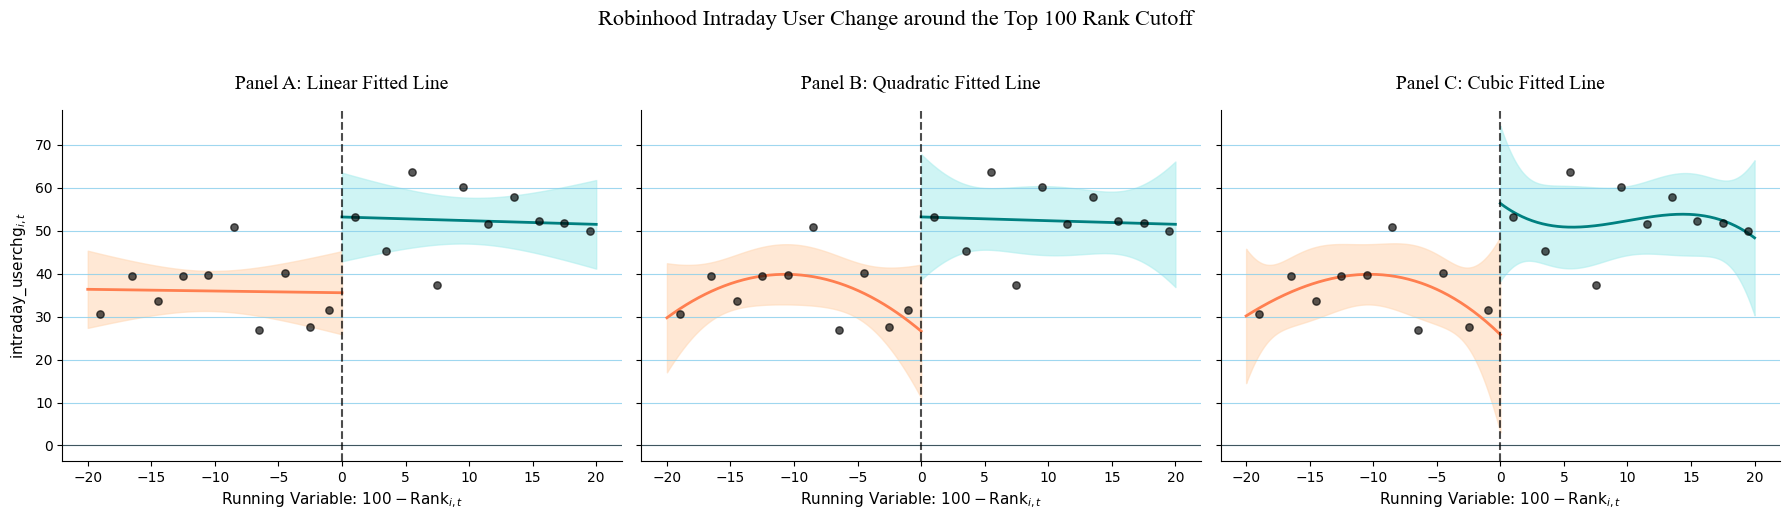

In [192]:
# ============================================================
# RUN: Default outcome userchg
# ============================================================

df4 = pd.read_csv("../../../data/processed/herding_events_full.csv")
df4["date"] = pd.to_datetime(df4["date"])

rd_df_rank = prepare_top100_rank_rd_data(
    df4,
    y_col="intraday_userchg",
    users_col="users_close",
    date_col="date",
    id_col="permno",          # use "ticker" if needed
    cutoff_rank=100,
    bandwidth=20,             # keeps rank_running from -20 to +20
    winsorize=True,
    winsor_upper_q=0.998,     # default requested
    winsor_lower_q=None
)

binned_rank_plot = plot_top100_rank_figure5_style(
    rd_df_rank,
    x_col="rank_running",
    y_col="y_plot",
    cutoff=0,
    degrees=(1, 2, 3),
    n_bins_each_side=10,
    figsize=(18, 5),
    y_label=r"$\mathrm{intraday\_userchg}_{i,t}$",
    title="Robinhood Intraday User Change around the Top 100 Rank Cutoff",
    save_path="../../../assets/figures/Top100_RankCutoff_IntradayUserchg.pdf"
)

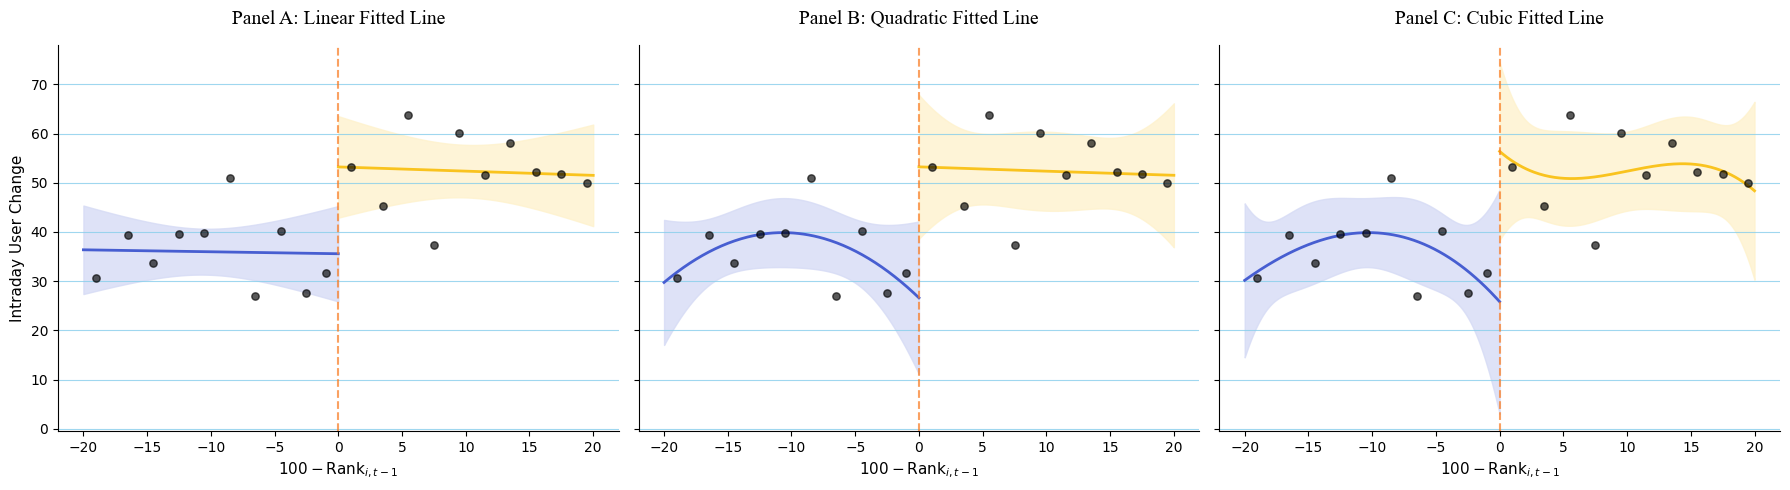

In [212]:
binned_rank_plot = plot_top100_rank_figure5_style(
    rd_df_rank,
    x_col="rank_running",
    y_col="y_plot",
    cutoff=0,
    degrees=(1, 2, 3),
    n_bins_each_side=10,
    figsize=(18, 5),
    x_label=r"$100 - \mathrm{Rank}_{i,t-1}$",
    y_label=r"Intraday User Change",
    ci_alpha=0.8,
    title=None,
    save_path="../../../assets/figures/Top100_RankCutoff_IntradayUserchg.pdf"
)

## RD Estimates

In [213]:
# ============================================================
# Top 100 Rank-Cutoff RD Coefficients
# Current experiment: lagged Top 100 visibility -> day-t userchg
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


# ============================================================
# 1. Build Top 100 rank RD sample
# ============================================================

def build_top100_rank_rd_sample(
    df,
    outcome="intraday_userchg",
    users_col="users_close",
    date_col="date",
    id_col="permno",
    cutoff_rank=100,
    bandwidth=20,
    use_lagged_rank=True,
    winsorize_outcome=True,
    winsor_upper_q=0.998,
    winsor_lower_q=None,
    rank_method="first"
):
    """
    Build RD sample around Robinhood's Top 100 rank cutoff.

    Main design:
        Treatment is based on rank at t-1.
        Outcome is measured on day t.

    Running variable:
        running = 100 - Rank_{i,t-1}

    Treatment:
        D = 1{Rank_{i,t-1} <= 100}

    Outcome:
        outcome_{i,t}, e.g. intraday_userchg or userchg.

    Parameters
    ----------
    df : pd.DataFrame
        Stock-day panel.

    outcome : str
        Dependent variable. Default: 'intraday_userchg'.

    users_col : str
        Variable used to rank stocks. Default: 'users_close'.

    date_col : str
        Trading date column.

    id_col : str
        Stock identifier. Prefer 'permno'. Use 'ticker' if needed.

    cutoff_rank : int
        Rank cutoff. Default is 100.

    bandwidth : int
        Rank bandwidth around cutoff.
        Example: bandwidth=20 keeps observations with running in [-20, 20],
        i.e. approximately ranks 80 to 120.

    use_lagged_rank : bool
        If True, treatment/running variable are based on day t-1 rank.
        This is the preferred causal design.

    winsorize_outcome : bool
        Whether to winsorize the outcome.

    winsor_upper_q : float
        Upper quantile for winsorization. Default 0.998.

    winsor_lower_q : float or None
        Optional lower quantile for two-sided winsorization.

    rank_method : str
        pandas rank method. 'first' ensures exactly 100 stocks per day,
        assuming at least 100 observations exist.

    Returns
    -------
    rd_df : pd.DataFrame
        Restricted RD sample.
    """

    data = df.copy()
    data = data.loc[:, ~data.columns.duplicated()].copy()

    if date_col not in data.columns:
        raise ValueError(f"Missing date column: {date_col}")
    if users_col not in data.columns:
        raise ValueError(f"Missing ranking column: {users_col}")
    if outcome not in data.columns:
        raise ValueError(f"Missing outcome column: {outcome}")
    if id_col not in data.columns:
        raise ValueError(f"Missing identifier column: {id_col}")

    data[date_col] = pd.to_datetime(data[date_col])

    # Keep relevant columns
    keep_cols = [date_col, id_col, users_col, outcome]

    optional_cols = [
        "ticker",
        "ret",
        "vol",
        "prc",
        "asvi",
        "num_news",
        "num_news_relevant",
        "ess",
        "css",
        "anl_chg"
    ]

    keep_cols += [c for c in optional_cols if c in data.columns and c not in keep_cols]
    data = data[keep_cols].copy()

    data = data.dropna(subset=[date_col, id_col, users_col, outcome]).copy()

    # Deduplicate stock-date observations
    n_dups = data.duplicated(subset=[id_col, date_col]).sum()
    if n_dups > 0:
        print(f"Duplicate stock-date observations found: {n_dups}. Keeping last by {users_col}.")
        data = (
            data.sort_values([date_col, id_col, users_col])
                .drop_duplicates(subset=[id_col, date_col], keep="last")
                .copy()
        )

    data = data.sort_values([id_col, date_col]).copy()

    # Trading-day index
    trading_days = pd.Series(sorted(data[date_col].unique()))
    trading_day_map = pd.Series(np.arange(len(trading_days)), index=trading_days)
    data["td"] = data[date_col].map(trading_day_map)

    # Daily rank by Robinhood users
    data["rh_rank"] = (
        data.groupby(date_col)[users_col]
            .rank(method=rank_method, ascending=False)
    )

    # Current-day treatment and running variable
    data["top100"] = (data["rh_rank"] <= cutoff_rank).astype(int)
    data["running"] = cutoff_rank - data["rh_rank"]

    if use_lagged_rank:
        # Lag rank, treatment, running variable
        data["rh_rank_lag1"] = data.groupby(id_col)["rh_rank"].shift(1)
        data["top100_lag1"] = data.groupby(id_col)["top100"].shift(1)
        data["running_lag1"] = data.groupby(id_col)["running"].shift(1)

        # Ensure the lag is the previous trading day
        data["td_lag1"] = data.groupby(id_col)["td"].shift(1)
        data["has_previous_trading_day_obs"] = (data["td"] - data["td_lag1"] == 1)

        data["D"] = data["top100_lag1"]
        data["rd_running"] = data["running_lag1"]
        data["rd_rank"] = data["rh_rank_lag1"]

        data = data.loc[data["has_previous_trading_day_obs"]].copy()

    else:
        # Not recommended if outcome is same-day userchg
        data["D"] = data["top100"]
        data["rd_running"] = data["running"]
        data["rd_rank"] = data["rh_rank"]

    # Restrict to bandwidth
    rd_df = data.loc[
        data["rd_running"].between(-bandwidth, bandwidth)
    ].copy()

    rd_df = rd_df.dropna(subset=[outcome, "D", "rd_running", "rd_rank"]).copy()

    # Winsorize outcome
    rd_df["outcome_raw"] = rd_df[outcome].astype(float)
    rd_df["outcome_w"] = rd_df["outcome_raw"]

    if winsorize_outcome:
        upper = rd_df["outcome_w"].quantile(winsor_upper_q)

        if winsor_lower_q is not None:
            lower = rd_df["outcome_w"].quantile(winsor_lower_q)
            rd_df["outcome_w"] = rd_df["outcome_w"].clip(lower=lower, upper=upper)
            print(f"Winsorized {outcome}: lower q={winsor_lower_q}, upper q={winsor_upper_q}")
            print(f"Bounds: [{lower:.4f}, {upper:.4f}]")
        else:
            rd_df["outcome_w"] = rd_df["outcome_w"].clip(upper=upper)
            print(f"Winsorized {outcome}: upper q={winsor_upper_q}")
            print(f"Upper bound: {upper:.4f}")

    print("\nRD sample diagnostics:")
    print("Total observations:", len(rd_df))
    print("Inside-cutoff observations:", int((rd_df["D"] == 1).sum()))
    print("Outside-cutoff observations:", int((rd_df["D"] == 0).sum()))
    print("Unique dates:", rd_df[date_col].nunique())
    print("Unique stocks:", rd_df[id_col].nunique())
    print("\nRank summary by treatment side:")
    print(rd_df.groupby("D")["rd_rank"].describe())
    print("\nOutcome summary by treatment side:")
    print(rd_df.groupby("D")["outcome_w"].describe())

    return rd_df

In [214]:
# ============================================================
# 2. Estimate RD on restricted Top 100 rank sample
# ============================================================

def run_top100_rank_rd(
    rd_df,
    outcome_col="outcome_w",
    degree=1,
    cluster="date",
    add_date_fe=False,
    controls=None
):
    """
    Estimate rank-cutoff RD:

        outcome = beta0
                + beta1 * D
                + polynomial(rd_running)
                + D * polynomial(rd_running)
                + controls
                + optional date FE
                + error

    Parameters
    ----------
    rd_df : pd.DataFrame
        Output of build_top100_rank_rd_sample().

    outcome_col : str
        Usually 'outcome_w' if winsorized, or 'outcome_raw'.

    degree : int
        Polynomial degree.

    cluster : str or None
        Cluster variable. Default 'date'.
        If None, uses HC1 robust standard errors.

    add_date_fe : bool
        Whether to include date fixed effects.
        For your visual/RD coefficient table, I would report both.
        Date FE are sensible because ranks are assigned within day.

    controls : list[str] or None
        Optional controls. Use only variables available in rd_df.

    Returns
    -------
    results : statsmodels results object
    """

    if rd_df.empty:
        raise ValueError("rd_df is empty.")

    df_reg = rd_df.copy()

    # Polynomial terms
    for n in range(1, degree + 1):
        df_reg[f"run{n}"] = df_reg["rd_running"] ** n
        df_reg[f"D_run{n}"] = df_reg["D"] * df_reg[f"run{n}"]

    rhs = ["D"]

    for n in range(1, degree + 1):
        rhs.append(f"run{n}")
        rhs.append(f"D_run{n}")

    if controls is not None:
        valid_controls = [c for c in controls if c in df_reg.columns]
        rhs.extend(valid_controls)
    else:
        valid_controls = []

    if add_date_fe:
        rhs.append("C(date)")

    formula = f"{outcome_col} ~ " + " + ".join(rhs)

    required = [outcome_col, "D", "rd_running"] + valid_controls
    model_data = df_reg.dropna(subset=required).copy()

    model = smf.ols(formula, data=model_data)

    if cluster is not None:
        results = model.fit(
            cov_type="cluster",
            cov_kwds={"groups": model_data[cluster]}
        )
    else:
        results = model.fit(cov_type="HC1")

    return results

In [215]:
# ============================================================
# 3. Diagnostics
# ============================================================

def top100_rank_rd_diagnostics(rd_df):
    """
    Basic diagnostics for Top 100 rank RD sample.
    """
    if rd_df.empty:
        print("RD sample is empty.")
        return

    print("Total observations:", len(rd_df))
    print("Inside Top 100 observations:", int((rd_df["D"] == 1).sum()))
    print("Outside Top 100 observations:", int((rd_df["D"] == 0).sum()))
    print("Unique dates:", rd_df["date"].nunique())

    if "permno" in rd_df.columns:
        print("Unique permnos:", rd_df["permno"].nunique())
    if "ticker" in rd_df.columns:
        print("Unique tickers:", rd_df["ticker"].nunique())

    print("\nRunning variable summary by side:")
    print(rd_df.groupby("D")["rd_running"].describe())

    print("\nRank summary by side:")
    print(rd_df.groupby("D")["rd_rank"].describe())

    print("\nOutcome summary by side:")
    print(rd_df.groupby("D")["outcome_w"].describe())

    if "ret" in rd_df.columns:
        print("\nReturn balance by side:")
        print(rd_df.groupby("D")["ret"].describe())

    if "asvi" in rd_df.columns:
        print("\nASVI balance by side:")
        print(rd_df.groupby("D")["asvi"].describe())

In [225]:
# ============================================================
# 4. Run baseline experiment
# ============================================================

# Choose the dependent variable.
# Use "intraday_userchg" if this is your actual intraday column.
# In your dataset, you may also have "userchg_intraday".
# If not, use "userchg".
OUTCOME = "intraday_userchg"

if OUTCOME not in df4.columns:
    if "userchg_intraday" in df4.columns:
        OUTCOME = "userchg_intraday"
    else:
        OUTCOME = "userchg"

print("Outcome used:", OUTCOME)

rd_df_top100 = build_top100_rank_rd_sample(
    df4,
    outcome=OUTCOME,
    users_col="users_close",
    date_col="date",
    id_col="permno",
    cutoff_rank=100,
    bandwidth=25,
    use_lagged_rank=False,
    winsorize_outcome=True,
    winsor_upper_q=0.998,
    winsor_lower_q=None
)

top100_rank_rd_diagnostics(rd_df_top100)

# Estimate linear, quadratic, cubic RD
res_lin = run_top100_rank_rd(
    rd_df_top100,
    outcome_col="outcome_w",
    degree=1,
    cluster="date",
    add_date_fe=False
)

res_quad = run_top100_rank_rd(
    rd_df_top100,
    outcome_col="outcome_w",
    degree=2,
    cluster="date",
    add_date_fe=False
)

res_cubic = run_top100_rank_rd(
    rd_df_top100,
    outcome_col="outcome_w",
    degree=3,
    cluster="date",
    add_date_fe=False
)

print("\n================ LINEAR RD ================\n")
print(res_lin.summary())

print("\n================ QUADRATIC RD ================\n")
print(res_quad.summary())

print("\n================ CUBIC RD ================\n")
print(res_cubic.summary())

Outcome used: intraday_userchg
Winsorized intraday_userchg: upper q=0.998
Upper bound: 4240.2540

RD sample diagnostics:
Total observations: 28254
Inside-cutoff observations: 14404
Outside-cutoff observations: 13850
Unique dates: 554
Unique stocks: 350

Rank summary by treatment side:
     count   mean       std    min    25%    50%    75%    max
D                                                             
0  13850.0  113.0  7.211363  101.0  107.0  113.0  119.0  125.0
1  14404.0   87.5  7.500260   75.0   81.0   87.5   94.0  100.0

Outcome summary by treatment side:
     count       mean         std     min   25%  50%   75%       max
D                                                                   
0  13850.0  36.983653  305.484898 -3101.0 -18.0  1.0  31.0  4240.254
1  14404.0  53.656824  357.542274 -8625.0 -21.0  3.0  43.0  4240.254
Total observations: 28254
Inside Top 100 observations: 14404
Outside Top 100 observations: 13850
Unique dates: 554
Unique permnos: 350
Unique tickers: